# Exploratory Data Analysis — HAM10000 Dermatoscopic Image Dataset

**Course:** Images and Computer Vision  
**Dataset:** HAM10000 — Human Against Machine with 10,000 Training Images  
**Challenge:** ISIC 2018 Challenge, Task 3 — Lesion Diagnosis  
**Reference:** Tschandl, P., Rosendahl, C. & Kittler, H. *The HAM10000 dataset, a large collection of multi-source dermatoscopic images of common pigmented skin lesions.* Sci. Data 5, 180161 (2018).  

---

## Abstract

This notebook presents a comprehensive Exploratory Data Analysis (EDA) of the HAM10000 dataset, which contains 10,015 dermatoscopic images of pigmented skin lesions across 7 diagnostic categories. The analysis covers metadata profiling, image property inspection, class imbalance characterisation, lesion-level grouping, segmentation mask quality, and test-set statistics. Key findings and implications for deep learning model development are discussed at the close of each section and consolidated in the Conclusions.

---

## 0 — Setup and Configuration

All third-party imports, global constants, and utility functions are centralised in this cell to keep the rest of the notebook clean and reproducible.

In [2]:
# ─── Standard library ────────────────────────────────────────────────────────
import os
import glob
import warnings
from pathlib import Path
from collections import Counter

# ─── Data manipulation ───────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ─── Visualisation ───────────────────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ─── Image I/O ───────────────────────────────────────────────────────────────
from PIL import Image, UnidentifiedImageError
import cv2

# ─── Progress bar ────────────────────────────────────────────────────────────
from tqdm.notebook import tqdm

# ─── Global settings ─────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
matplotlib.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

SEED = 42
np.random.seed(SEED)

# ─── Dataset paths ───────────────────────────────────────────────────────────
BASE_DIR = Path(r'f:/U/10 mo Semestre/Imagenes y vision/Pf final/dataverse_files')

METADATA_PATH  = BASE_DIR / 'HAM10000_metadata'
GT_TEST_PATH   = BASE_DIR / 'ISIC2018_Task3_Test_GroundTruth.csv'
AI_STUDY_PATH  = BASE_DIR / 'ISIC2018_Task3_Test_NatureMedicine_AI_Interaction_Benefit.csv'

IMG_PART1_DIR  = BASE_DIR / 'HAM10000_images_part_1'
IMG_PART2_DIR  = BASE_DIR / 'HAM10000_images_part_2'
SEG_DIR        = BASE_DIR / 'HAM10000_segmentations_lesion_tschandl' / 'HAM10000_segmentations_lesion_tschandl'
TEST_IMG_DIR   = BASE_DIR / 'ISIC2018_Task3_Test_Images' / 'ISIC2018_Task3_Test_Images'

# ─── Class label mapping ────────────────────────────────────────────────────
CLASS_LABELS = {
    'mel':   'Melanoma',
    'nv':    'Melanocytic Nevi',
    'bcc':   'Basal Cell Carcinoma',
    'akiec': 'Actinic Keratosis / Intraepithelial Carcinoma',
    'bkl':   'Benign Keratosis-like Lesions',
    'df':    'Dermatofibroma',
    'vasc':  'Vascular Lesions',
}

CLASS_PALETTE = {
    'mel':   '#E63946',
    'nv':    '#457B9D',
    'bcc':   '#F4A261',
    'akiec': '#2A9D8F',
    'bkl':   '#8338EC',
    'df':    '#06D6A0',
    'vasc':  '#FFB703',
}

print('All imports successful.')
print(f'Working directory : {BASE_DIR}')
print(f'Metadata file     : {METADATA_PATH.name}')

All imports successful.
Working directory : f:\U\10 mo Semestre\Imagenes y vision\Pf final\dataverse_files
Metadata file     : HAM10000_metadata


### Utility functions

Reusable helpers referenced throughout the notebook.

In [4]:
def resolve_image_path(image_id: str) -> Path | None:
    """Return the full path for a given image_id, searching both part directories."""
    for d in (IMG_PART1_DIR, IMG_PART2_DIR):
        p = d / f'{image_id}.jpg'
        if p.exists():
            return p
    return None


def resolve_mask_path(image_id: str) -> Path | None:
    """Return the full path for the segmentation mask of a given image_id."""
    p = SEG_DIR / f'{image_id}_segmentation.png'
    return p if p.exists() else None


def load_image_pil(path: Path) -> Image.Image | None:
    """Load an image with PIL, returning None on failure."""
    try:
        return Image.open(path).convert('RGB')
    except (UnidentifiedImageError, OSError):
        return None


def load_image_cv2(path: Path) -> np.ndarray | None:
    """Load an image with OpenCV (BGR), returning None on failure."""
    img = cv2.imread(str(path))
    return img


def plot_countplot(ax, data, column, palette, title, xlabel, ylabel='Count',
                   rotation=0, annotate=True):
    """Styled count bar plot on a given Axes object."""
    order = data[column].value_counts().index
    colors = [palette.get(v, '#888888') for v in order] if isinstance(palette, dict) else None
    sns.countplot(ax=ax, data=data, x=column, order=order,
                  palette=colors if colors else palette)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=rotation)
    if annotate:
        for p in ax.patches:
            ax.annotate(f'{int(p.get_height()):,}',
                        (p.get_x() + p.get_width() / 2, p.get_height()),
                        ha='center', va='bottom', fontsize=9)


print('Utility functions defined.')

Utility functions defined.


---
## 1 — Dataset Overview

This section inventories all files on-disk and relates them to the official dataset statistics.

### 1.1 File inventory

In [5]:
# Count files in each relevant directory
part1_files = sorted(IMG_PART1_DIR.glob('*.jpg'))
part2_files = sorted(IMG_PART2_DIR.glob('*.jpg'))
seg_files   = sorted(SEG_DIR.glob('*.png')) if SEG_DIR.exists() else []
test_files  = sorted(TEST_IMG_DIR.glob('*.jpg')) if TEST_IMG_DIR.exists() else []

all_train_files = part1_files + part2_files

print('=== File inventory ===')
print(f'  Training images  — Part 1       : {len(part1_files):>6,}')
print(f'  Training images  — Part 2       : {len(part2_files):>6,}')
print(f'  Training images  — Total        : {len(all_train_files):>6,}')
print(f'  Segmentation masks               : {len(seg_files):>6,}')
print(f'  Test images                      : {len(test_files):>6,}')
print()
print(f'  Metadata CSV     : {METADATA_PATH.name}')
print(f'  Test GT CSV      : {GT_TEST_PATH.name}')
print(f'  AI Study CSV     : {AI_STUDY_PATH.name}')

=== File inventory ===
  Training images  — Part 1       :  5,000
  Training images  — Part 2       :  5,015
  Training images  — Total        : 10,015
  Segmentation masks               : 10,015
  Test images                      :  1,511

  Metadata CSV     : HAM10000_metadata
  Test GT CSV      : ISIC2018_Task3_Test_GroundTruth.csv
  AI Study CSV     : ISIC2018_Task3_Test_NatureMedicine_AI_Interaction_Benefit.csv


### 1.2 Load metadata

In [6]:
# HAM10000_metadata has no file extension but is a standard comma-separated CSV
df = pd.read_csv(METADATA_PATH)
df_test_gt = pd.read_csv(GT_TEST_PATH)

print('Training metadata shape :', df.shape)
print('Test GT metadata shape  :', df_test_gt.shape)
df.head()

Training metadata shape : (10015, 8)
Test GT metadata shape  : (1512, 8)


,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset
0,HAM_0000118,ISIC_0027419,bkl,histo,80.00,male,scalp,vidir_modern
1,HAM_0000118,ISIC_0025030,bkl,histo,80.00,male,scalp,vidir_modern
2,HAM_0002730,ISIC_0026769,bkl,histo,80.00,male,scalp,vidir_modern
3,HAM_0002730,ISIC_0025661,bkl,histo,80.00,male,scalp,vidir_modern
4,HAM_0001466,ISIC_0031633,bkl,histo,75.00,male,ear,vidir_modern


In [7]:
# Data types and missing values
print('=== Column info (training metadata) ===')
info = pd.DataFrame({
    'dtype'   : df.dtypes,
    'non_null': df.notnull().sum(),
    'null'    : df.isnull().sum(),
    'null_%'  : (df.isnull().sum() / len(df) * 100).round(2),
    'unique'  : df.nunique(),
})
display(info)

=== Column info (training metadata) ===


,dtype,non_null,null,null_%,unique
lesion_id,str,10015,0,0.00,7470
image_id,str,10015,0,0.00,10015
dx,str,10015,0,0.00,7
dx_type,str,10015,0,0.00,4
age,float64,9958,57,0.57,18
sex,str,10015,0,0.00,3
localization,str,10015,0,0.00,15
dataset,str,10015,0,0.00,4


### 1.3 Key counts

In [8]:
n_images        = len(df)
n_unique_lesions = df['lesion_id'].nunique()
n_classes       = df['dx'].nunique()
classes         = sorted(df['dx'].unique())

print('=== Dataset key counts ===')
print(f'  Total records (images)  : {n_images:,}')
print(f'  Unique lesions          : {n_unique_lesions:,}')
print(f'  Diagnostic classes      : {n_classes}')
print()
print('  Classes :')
for c in classes:
    print(f'    {c:>6}  →  {CLASS_LABELS[c]}')

=== Dataset key counts ===
  Total records (images)  : 10,015
  Unique lesions          : 7,470
  Diagnostic classes      : 7

  Classes :
     akiec  →  Actinic Keratosis / Intraepithelial Carcinoma
       bcc  →  Basal Cell Carcinoma
       bkl  →  Benign Keratosis-like Lesions
        df  →  Dermatofibroma
       mel  →  Melanoma
        nv  →  Melanocytic Nevi
      vasc  →  Vascular Lesions


In [9]:
# Verify on-disk count matches metadata
on_disk_ids  = {p.stem for p in all_train_files}
metadata_ids = set(df['image_id'])

only_on_disk = on_disk_ids - metadata_ids
only_in_meta = metadata_ids - on_disk_ids

print(f'Images on disk not in metadata : {len(only_on_disk)}')
print(f'Images in metadata not on disk : {len(only_in_meta)}')
if len(only_in_meta) == 0 and len(only_on_disk) == 0:
    print('✓ Perfect 1-to-1 correspondence between metadata rows and image files.')

Images on disk not in metadata : 0
Images in metadata not on disk : 0
✓ Perfect 1-to-1 correspondence between metadata rows and image files.


---
## 2 — Metadata Profiling

Demographic and clinical attributes encoded in the metadata are analysed to understand the population covered by the dataset.

### 2.1 Diagnostic class distribution (dx)

,Label,Count,Percentage
Abbrev,,,
nv,Melanocytic Nevi,6705,66.95
mel,Melanoma,1113,11.11
bkl,Benign Keratosis-like Lesions,1099,10.97
bcc,Basal Cell Carcinoma,514,5.13
akiec,Actinic Keratosis / Intraepithelial Carcinoma,327,3.27
vasc,Vascular Lesions,142,1.42
df,Dermatofibroma,115,1.15


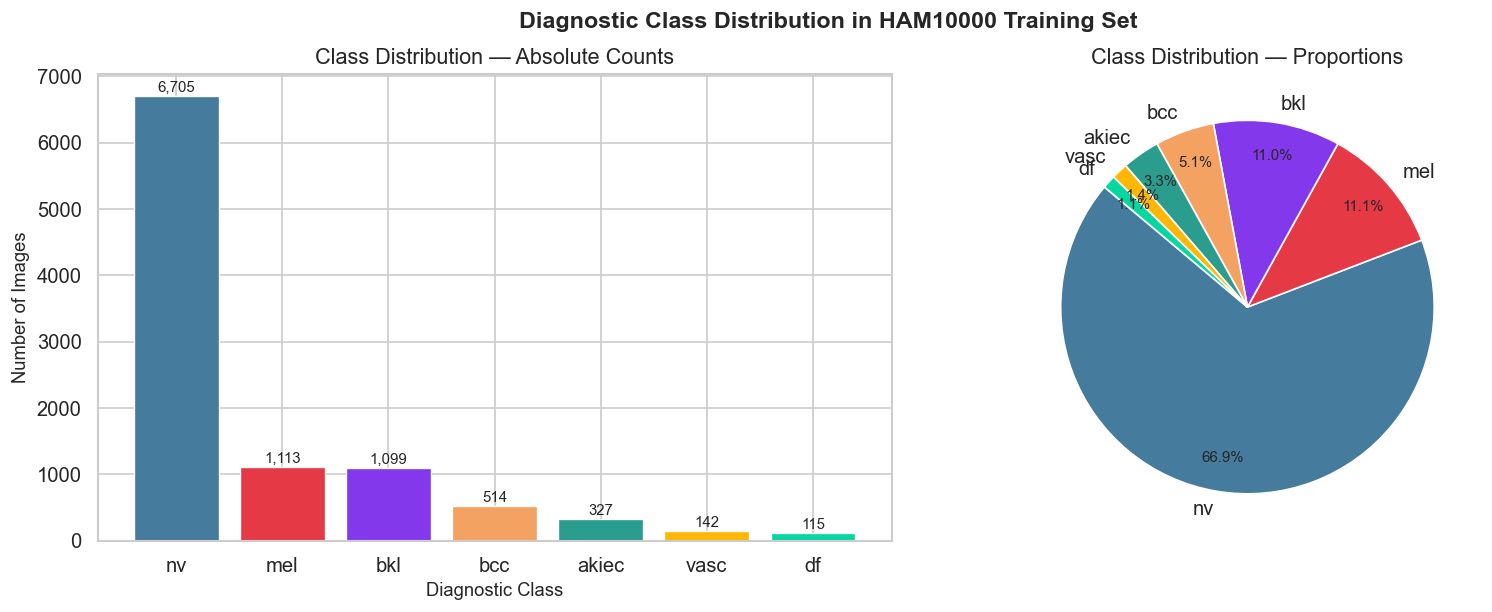

In [10]:
dx_counts = df['dx'].value_counts()
dx_pct    = (dx_counts / len(df) * 100).round(2)
dx_summary = pd.DataFrame({
    'Label'     : [CLASS_LABELS[c] for c in dx_counts.index],
    'Count'     : dx_counts.values,
    'Percentage': dx_pct.values,
    'Abbrev'    : dx_counts.index,
}).set_index('Abbrev')
display(dx_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = [CLASS_PALETTE[c] for c in dx_counts.index]
bars = axes[0].bar(dx_counts.index, dx_counts.values, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Class Distribution — Absolute Counts')
axes[0].set_xlabel('Diagnostic Class')
axes[0].set_ylabel('Number of Images')
for bar, val in zip(bars, dx_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
                 f'{val:,}', ha='center', va='bottom', fontsize=9)

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    dx_counts.values,
    labels=dx_counts.index,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.82,
)
for at in autotexts:
    at.set_fontsize(9)
axes[1].set_title('Class Distribution — Proportions')

plt.tight_layout()
plt.suptitle('Diagnostic Class Distribution in HAM10000 Training Set', y=1.02, fontsize=14, fontweight='bold')
plt.show()

> **Observation:** The dataset is severely imbalanced. *Melanocytic Nevi* (nv) alone accounts for roughly 67 % of all images, while minority classes such as *Dermatofibroma* (df) and *Vascular Lesions* (vasc) each represent less than 2 %. This imbalance will significantly affect training dynamics and must be addressed through stratified sampling, class-weighted loss, or data augmentation.

### 2.2 Diagnosis confirmation type (dx_type)

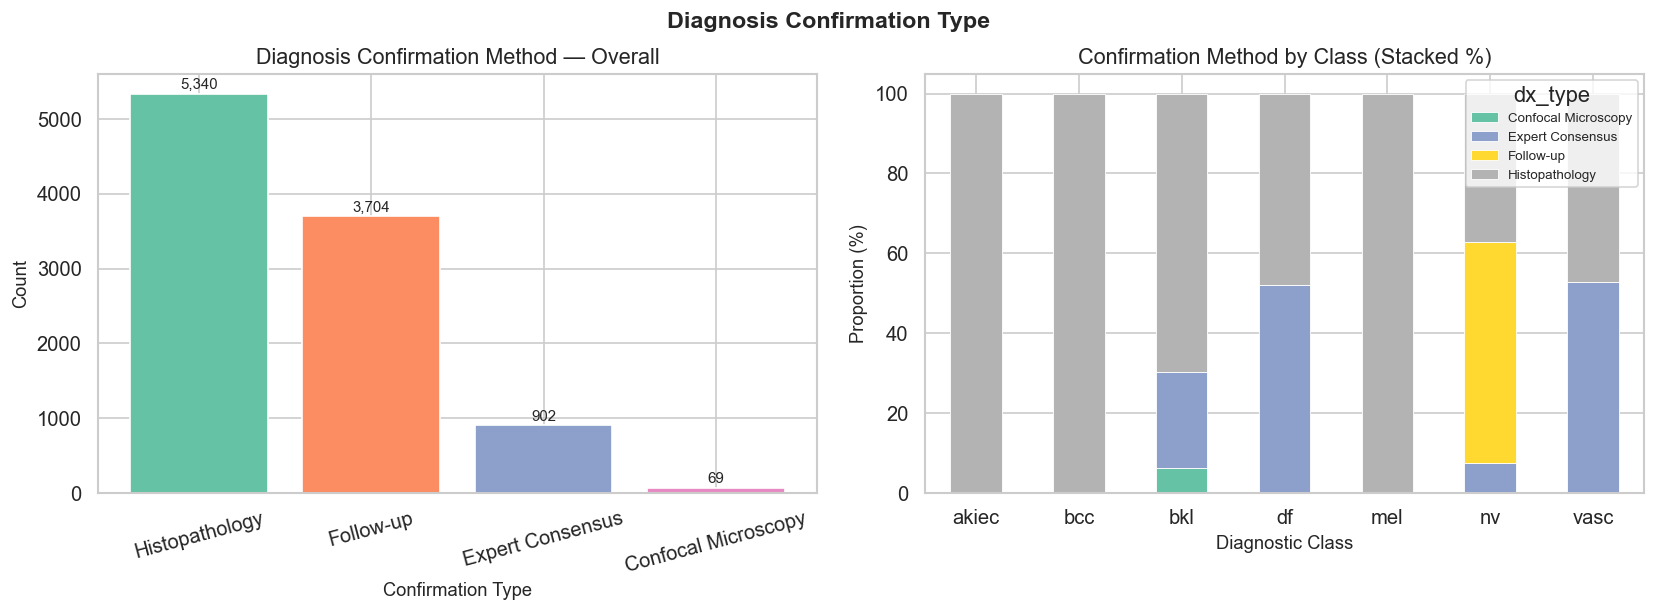

Cross-tabulation (count):


dx_type,confocal,consensus,follow_up,histo
dx,,,,
akiec,0,0,0,327
bcc,0,0,0,514
bkl,69,264,0,766
df,0,60,0,55
mel,0,0,0,1113
nv,0,503,3704,2498
vasc,0,75,0,67


In [11]:
dx_type_labels = {
    'histo'    : 'Histopathology',
    'follow_up': 'Follow-up',
    'consensus': 'Expert Consensus',
    'confocal' : 'Confocal Microscopy',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall distribution
dxt_counts = df['dx_type'].value_counts()
axes[0].bar(
    [dx_type_labels.get(k, k) for k in dxt_counts.index],
    dxt_counts.values,
    color=sns.color_palette('Set2', len(dxt_counts)),
    edgecolor='white',
)
axes[0].set_title('Diagnosis Confirmation Method — Overall')
axes[0].set_xlabel('Confirmation Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)
for p, v in zip(axes[0].patches, dxt_counts.values):
    axes[0].text(p.get_x() + p.get_width() / 2, p.get_height() + 20,
                 f'{v:,}', ha='center', va='bottom', fontsize=9)

# Cross-tabulation: dx vs dx_type
ct = pd.crosstab(df['dx'], df['dx_type'])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct_pct.plot(kind='bar', stacked=True, ax=axes[1],
            colormap='Set2', edgecolor='white', linewidth=0.5)
axes[1].set_title('Confirmation Method by Class (Stacked %)')
axes[1].set_xlabel('Diagnostic Class')
axes[1].set_ylabel('Proportion (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='dx_type', labels=[dx_type_labels.get(c, c) for c in ct_pct.columns],
               fontsize=8, loc='upper right')

plt.tight_layout()
plt.suptitle('Diagnosis Confirmation Type', y=1.02, fontsize=14, fontweight='bold')
plt.show()

print('Cross-tabulation (count):')
display(ct)

### 2.3 Patient age distribution

Missing age values: 57 (0.6%)


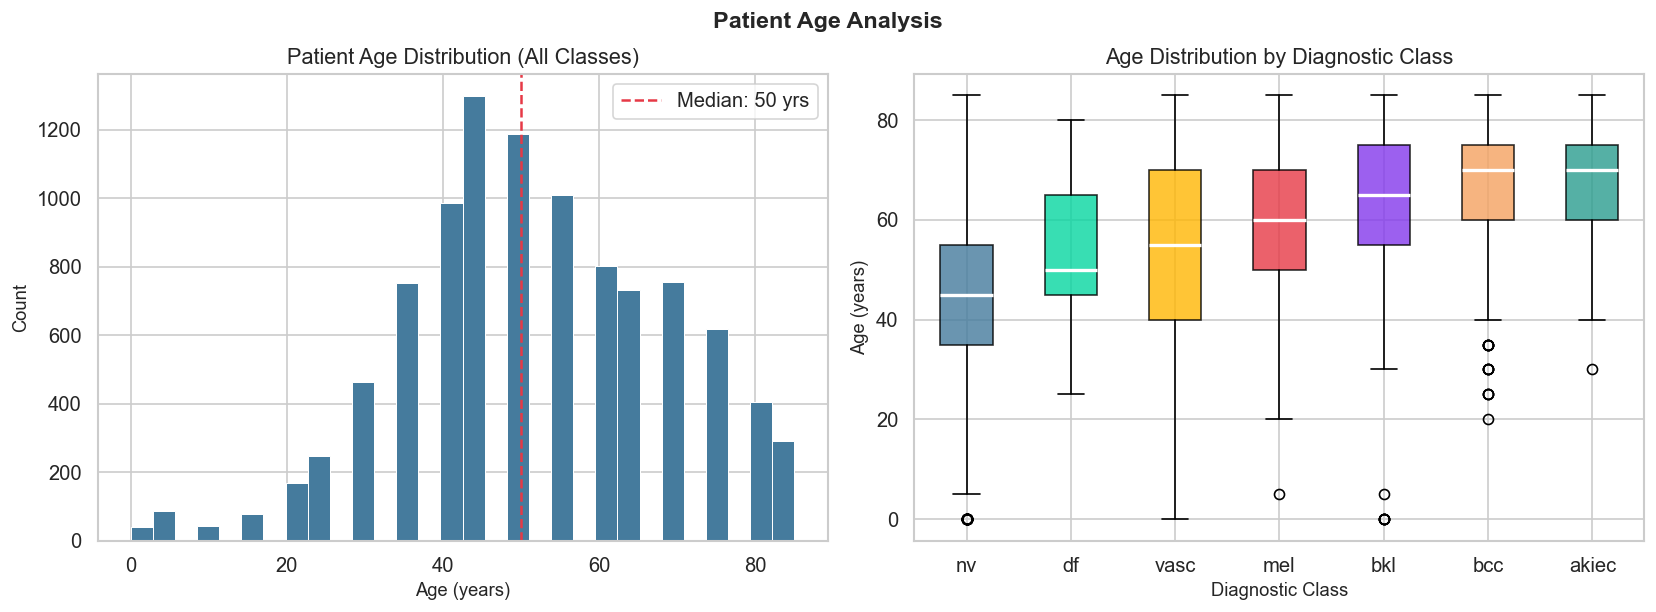

Age summary statistics:


,count,mean,std,min,25%,50%,75%,max
dx,,,,,,,,
akiec,327.00,66.50,11.50,30.00,60.00,70.00,75.00,85.00
bcc,514.00,66.80,13.70,20.00,60.00,70.00,75.00,85.00
bkl,1089.00,64.30,14.10,0.00,55.00,65.00,75.00,85.00
df,115.00,53.00,13.60,25.00,45.00,50.00,65.00,80.00
mel,1111.00,60.70,15.20,5.00,50.00,60.00,70.00,85.00
nv,6660.00,46.50,15.20,0.00,35.00,45.00,55.00,85.00
vasc,142.00,51.40,21.60,0.00,40.00,55.00,70.00,85.00


In [12]:
print(f'Missing age values: {df["age"].isna().sum()} ({df["age"].isna().mean()*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall histogram
axes[0].hist(df['age'].dropna(), bins=30, color='#457B9D', edgecolor='white', linewidth=0.6)
axes[0].axvline(df['age'].median(), color='#E63946', linestyle='--', linewidth=1.5,
                label=f'Median: {df["age"].median():.0f} yrs')
axes[0].set_title('Patient Age Distribution (All Classes)')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Box plot per class
order = df.groupby('dx')['age'].median().sort_values().index
colors_list = [CLASS_PALETTE[c] for c in order]
bp = axes[1].boxplot(
    [df.loc[df['dx'] == c, 'age'].dropna().values for c in order],
    labels=order,
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2),
)
for patch, color in zip(bp['boxes'], colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[1].set_title('Age Distribution by Diagnostic Class')
axes[1].set_xlabel('Diagnostic Class')
axes[1].set_ylabel('Age (years)')

plt.tight_layout()
plt.suptitle('Patient Age Analysis', y=1.02, fontsize=14, fontweight='bold')
plt.show()

print('Age summary statistics:')
display(df.groupby('dx')['age'].describe().round(1))

### 2.4 Sex distribution

Missing sex values: 0


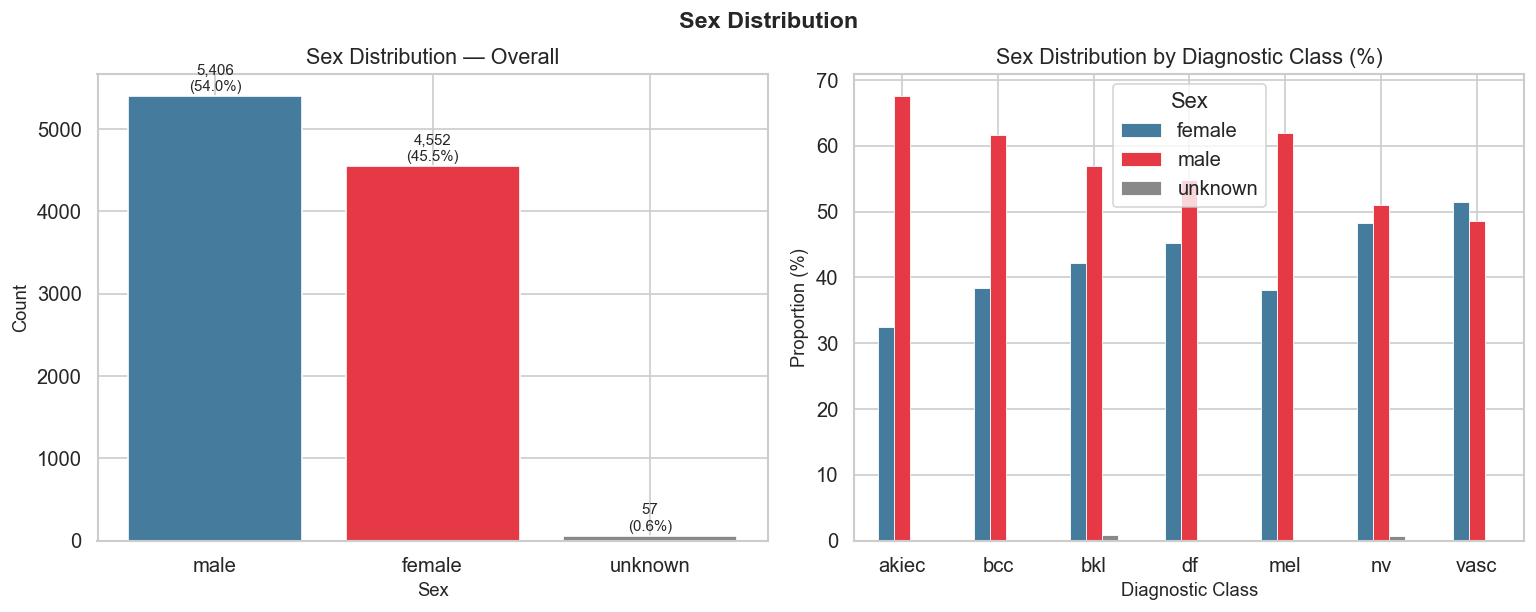

In [13]:
print(f'Missing sex values: {df["sex"].isna().sum()}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sex_counts = df['sex'].value_counts()
sex_palette = {'male': '#457B9D', 'female': '#E63946', 'unknown': '#888888'}
colors_sex = [sex_palette.get(s, '#888') for s in sex_counts.index]

axes[0].bar(sex_counts.index, sex_counts.values, color=colors_sex, edgecolor='white')
axes[0].set_title('Sex Distribution — Overall')
axes[0].set_xlabel('Sex')
axes[0].set_ylabel('Count')
for p, v in zip(axes[0].patches, sex_counts.values):
    axes[0].text(p.get_x() + p.get_width() / 2, p.get_height() + 30,
                 f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=9)

# Grouped bar: sex per class
sex_dx = df.groupby(['dx', 'sex']).size().unstack(fill_value=0)
sex_dx_pct = sex_dx.div(sex_dx.sum(axis=1), axis=0) * 100
sex_dx_pct.plot(kind='bar', ax=axes[1], color=colors_sex[:len(sex_dx_pct.columns)],
                edgecolor='white', linewidth=0.5)
axes[1].set_title('Sex Distribution by Diagnostic Class (%)')
axes[1].set_xlabel('Diagnostic Class')
axes[1].set_ylabel('Proportion (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Sex')

plt.tight_layout()
plt.suptitle('Sex Distribution', y=1.02, fontsize=14, fontweight='bold')
plt.show()

### 2.5 Anatomical localization

Unique localizations: 15
Missing values      : 0


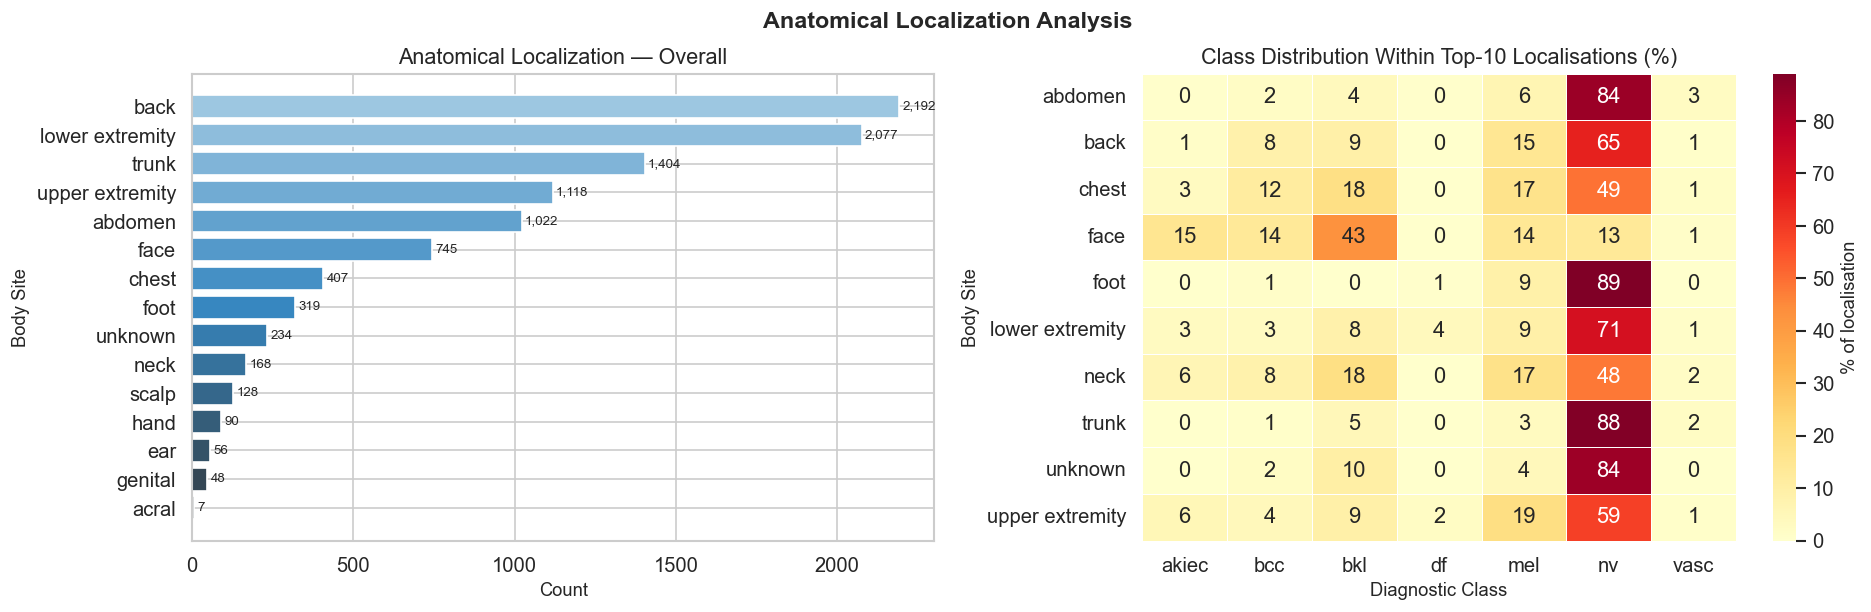

In [14]:
print(f'Unique localizations: {df["localization"].nunique()}')
print(f'Missing values      : {df["localization"].isna().sum()}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Overall localization
loc_counts = df['localization'].value_counts()
axes[0].barh(loc_counts.index[::-1], loc_counts.values[::-1],
             color=sns.color_palette('Blues_d', len(loc_counts))[::-1],
             edgecolor='white')
axes[0].set_title('Anatomical Localization — Overall')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Body Site')
for p in axes[0].patches:
    axes[0].text(p.get_width() + 10, p.get_y() + p.get_height() / 2,
                 f'{int(p.get_width()):,}', va='center', fontsize=8)

# Heatmap top 10 localisations × class
top_locs = loc_counts.head(10).index
loc_class = df[df['localization'].isin(top_locs)].groupby(['localization', 'dx']).size().unstack(fill_value=0)
loc_class_pct = loc_class.div(loc_class.sum(axis=1), axis=0) * 100
sns.heatmap(loc_class_pct, ax=axes[1], cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=0.4, cbar_kws={'label': '% of localisation'})
axes[1].set_title('Class Distribution Within Top-10 Localisations (%)')
axes[1].set_xlabel('Diagnostic Class')
axes[1].set_ylabel('Body Site')

plt.tight_layout()
plt.suptitle('Anatomical Localization Analysis', y=1.02, fontsize=14, fontweight='bold')
plt.show()

---
## 3 — Image Exploration

We inspect the physical properties of the image files: resolution, colour space, and integrity.

### 3.1 Build image path index

In [15]:
# Map each image_id → absolute path
path_index = {p.stem: p for p in all_train_files}
df['img_path'] = df['image_id'].map(path_index)

missing_paths = df['img_path'].isna().sum()
print(f'Images found    : {df["img_path"].notna().sum():,}')
print(f'Images missing  : {missing_paths}')

Images found    : 10,015
Images missing  : 0


### 3.2 Sample image dimensions

We sample 500 images to estimate the resolution distribution efficiently.

In [16]:
SAMPLE_N = 500
sample_df = df.dropna(subset=['img_path']).sample(SAMPLE_N, random_state=SEED)

widths, heights, channels_list, corrupted = [], [], [], []

for _, row in tqdm(sample_df.iterrows(), total=SAMPLE_N, desc='Reading image properties'):
    img = load_image_pil(row['img_path'])
    if img is None:
        corrupted.append(row['image_id'])
        continue
    w, h = img.size
    widths.append(w)
    heights.append(h)
    channels_list.append(len(img.getbands()))

print(f'\nSampled: {SAMPLE_N}')
print(f'Corrupted / unreadable: {len(corrupted)}')
print(f'Unique widths  : {sorted(set(widths))}')
print(f'Unique heights : {sorted(set(heights))}')
print(f'Unique channel counts: {sorted(set(channels_list))}')

Reading image properties:   0%|          | 0/500 [00:00<?, ?it/s]


Sampled: 500
Corrupted / unreadable: 0
Unique widths  : [600]
Unique heights : [450]
Unique channel counts: [3]


### 3.3 Resolution distribution

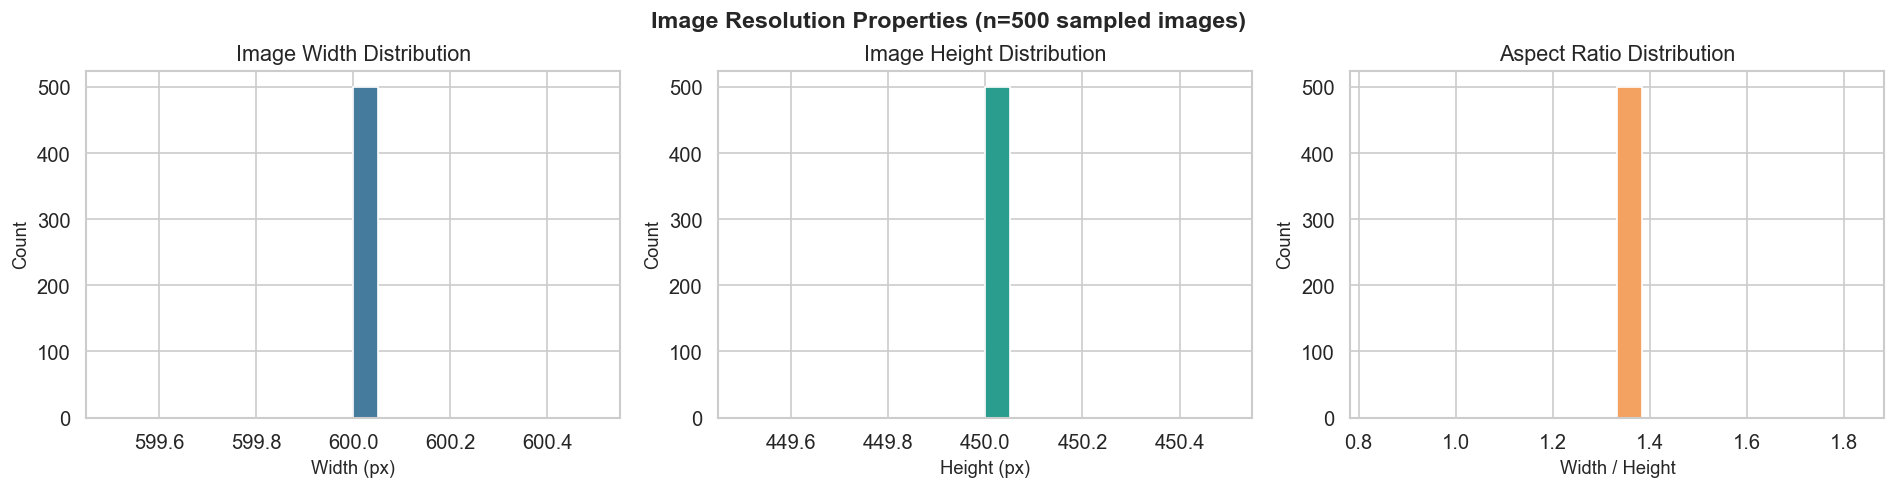

Mean width  : 600.0 px  |  Std: 0.0
Mean height : 450.0 px  |  Std: 0.0
Mean aspect : 1.333

Top-5 most common (W×H) resolutions:
  600×450  →  500 images


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(widths,  bins=20, color='#457B9D', edgecolor='white')
axes[0].set_title('Image Width Distribution')
axes[0].set_xlabel('Width (px)')
axes[0].set_ylabel('Count')

axes[1].hist(heights, bins=20, color='#2A9D8F', edgecolor='white')
axes[1].set_title('Image Height Distribution')
axes[1].set_xlabel('Height (px)')
axes[1].set_ylabel('Count')

aspect_ratios = [w / h for w, h in zip(widths, heights)]
axes[2].hist(aspect_ratios, bins=20, color='#F4A261', edgecolor='white')
axes[2].set_title('Aspect Ratio Distribution')
axes[2].set_xlabel('Width / Height')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.suptitle(f'Image Resolution Properties (n={SAMPLE_N} sampled images)', y=1.02,
             fontsize=14, fontweight='bold')
plt.show()

print(f'Mean width  : {np.mean(widths):.1f} px  |  Std: {np.std(widths):.1f}')
print(f'Mean height : {np.mean(heights):.1f} px  |  Std: {np.std(heights):.1f}')
print(f'Mean aspect : {np.mean(aspect_ratios):.3f}')

res_counts = Counter(zip(widths, heights))
print('\nTop-5 most common (W×H) resolutions:')
for res, cnt in res_counts.most_common(5):
    print(f'  {res[0]}×{res[1]}  →  {cnt} images')

### 3.4 Corrupted image detection (full scan)

In [18]:
corrupted_full = []

for path in tqdm(all_train_files, desc='Scanning all training images'):
    try:
        with Image.open(path) as img:
            img.verify()  # lightweight check without loading pixel data
    except Exception:
        corrupted_full.append(path.name)

print(f'\nTotal training images scanned : {len(all_train_files):,}')
print(f'Corrupted / invalid images    : {len(corrupted_full)}')
if corrupted_full:
    print('Corrupted files:')
    for f in corrupted_full:
        print(f'  {f}')

Scanning all training images:   0%|          | 0/10015 [00:00<?, ?it/s]


Total training images scanned : 10,015
Corrupted / invalid images    : 0


---
## 4 — Visual Exploration

We display representative image samples, RGB channel statistics, and average colour per class.

### 4.1 Curated image grid — random samples per class

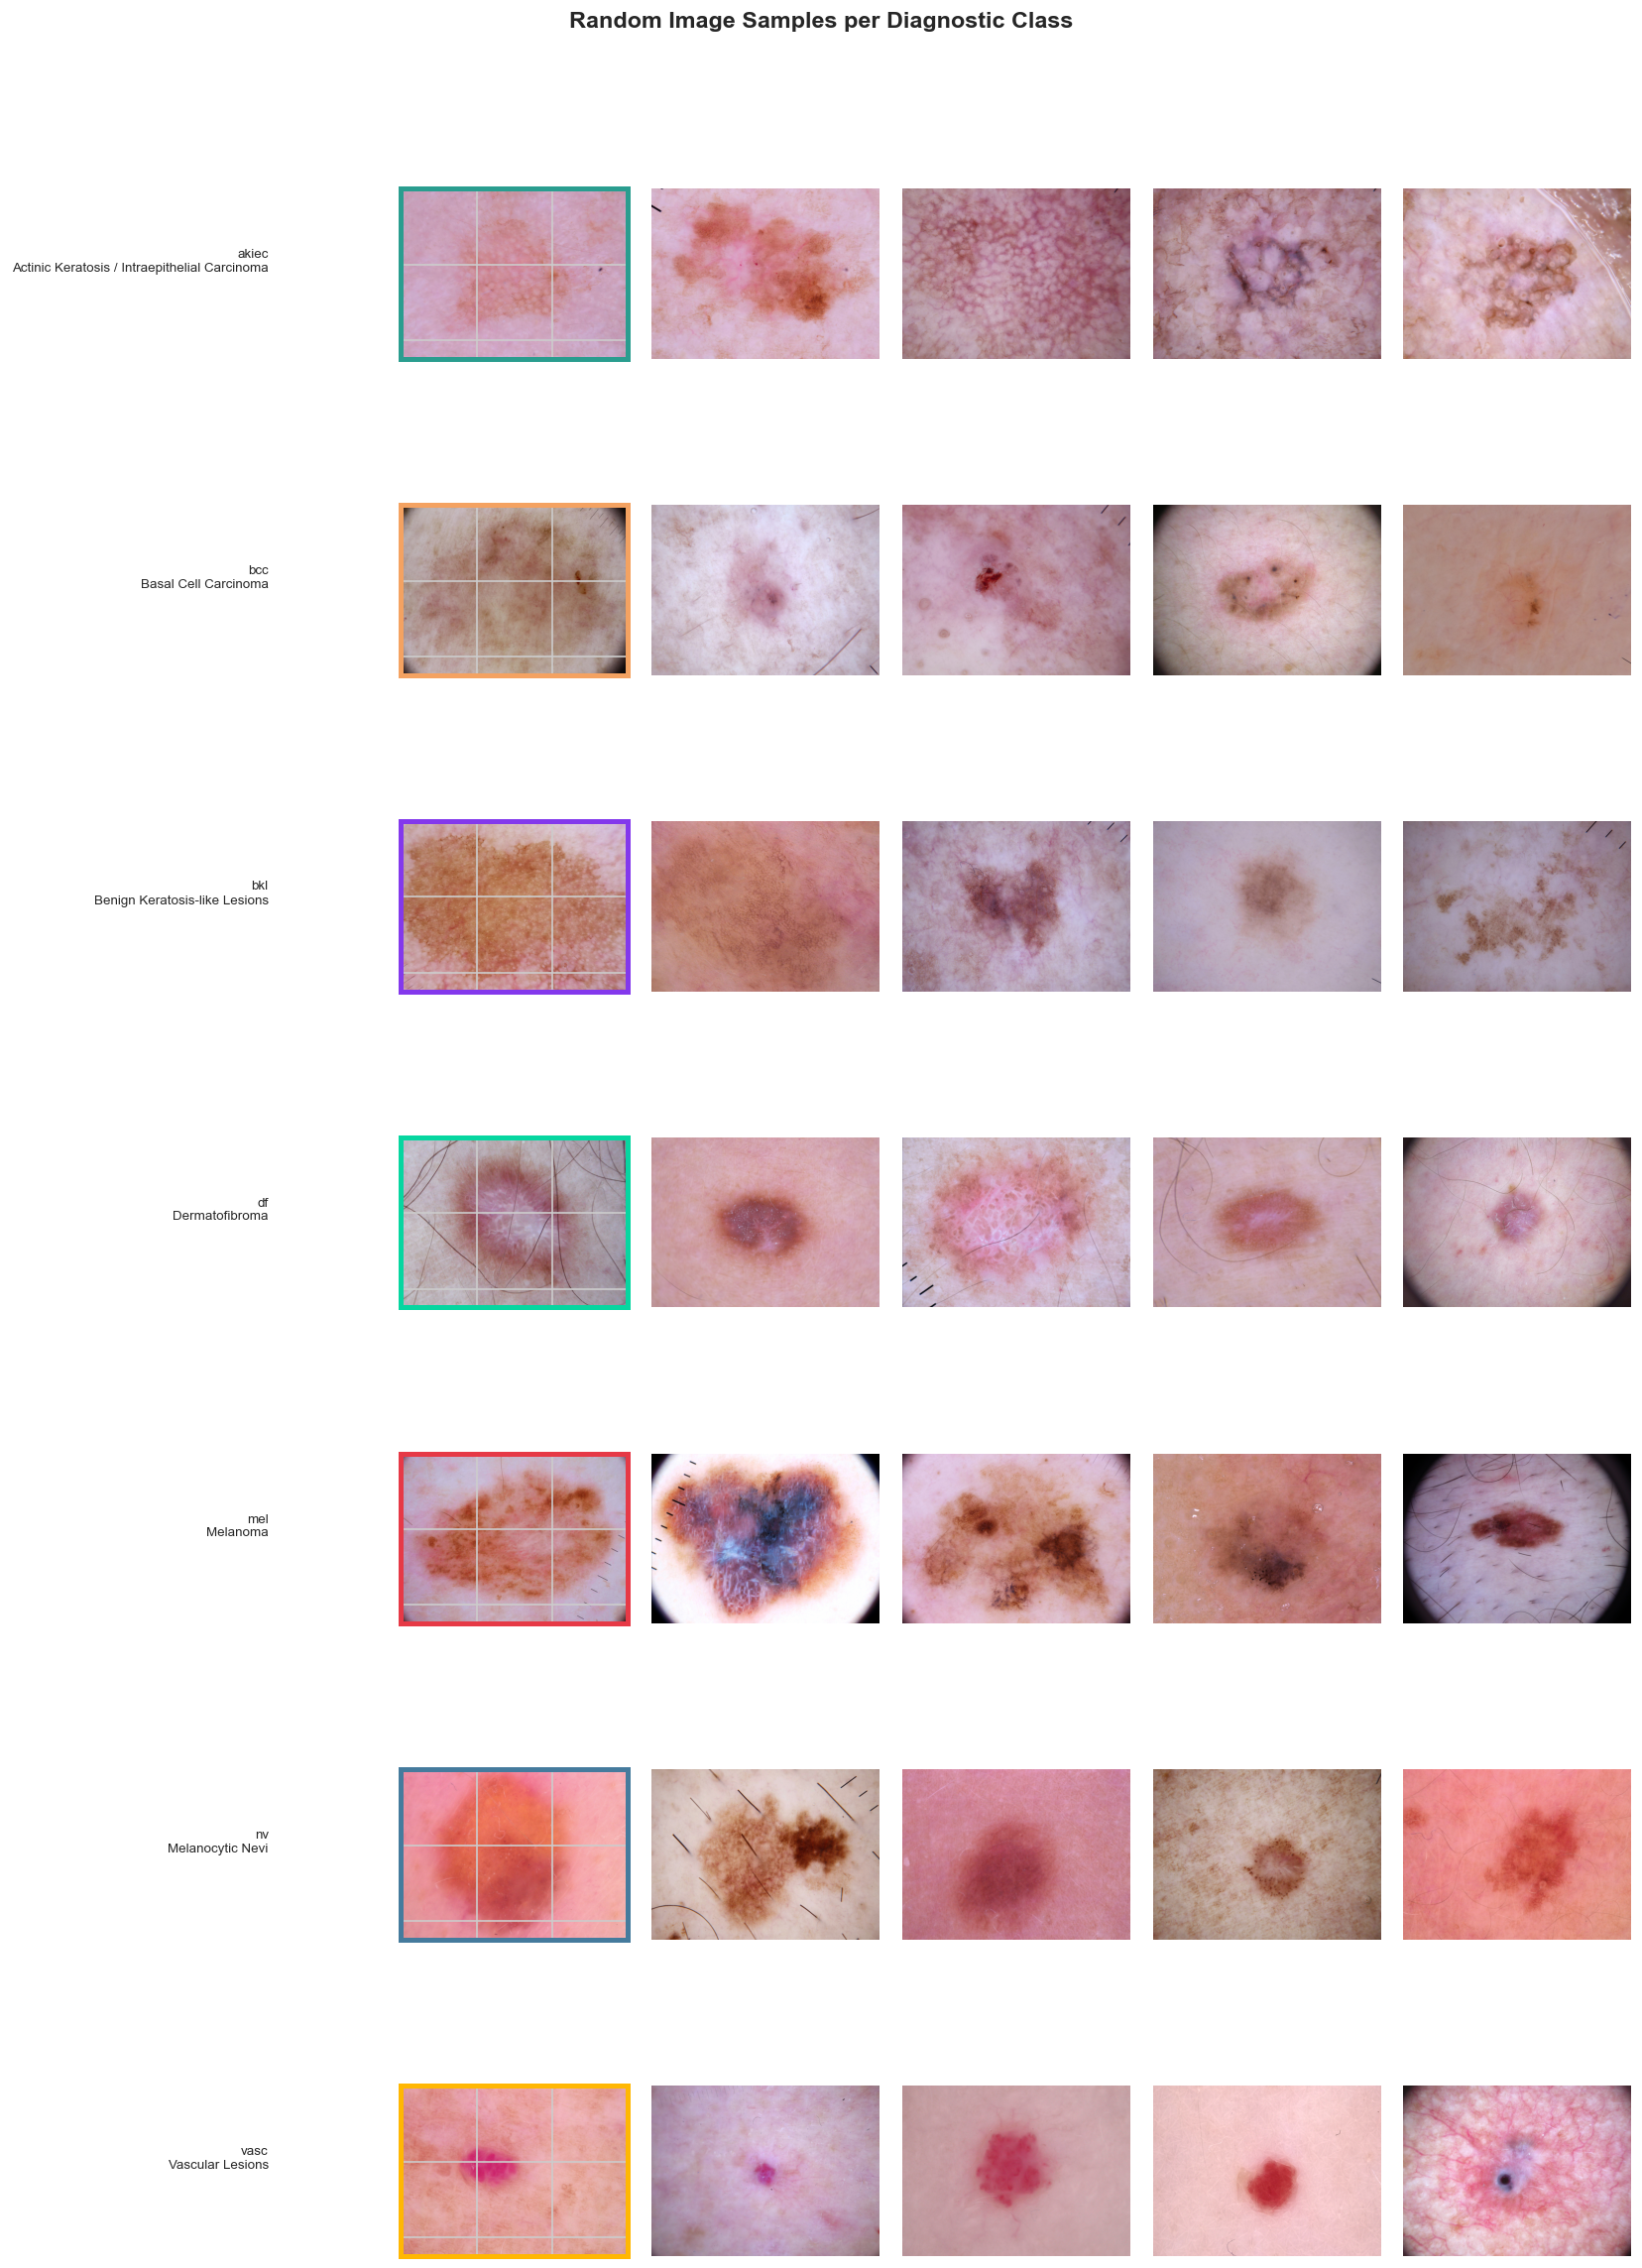

In [19]:
SAMPLES_PER_CLASS = 5

fig, axes = plt.subplots(len(classes), SAMPLES_PER_CLASS,
                          figsize=(SAMPLES_PER_CLASS * 2.8, len(classes) * 2.8))

for row_idx, cls in enumerate(classes):
    cls_df = df[df['dx'] == cls].dropna(subset=['img_path'])
    samples = cls_df.sample(min(SAMPLES_PER_CLASS, len(cls_df)), random_state=SEED)

    for col_idx in range(SAMPLES_PER_CLASS):
        ax = axes[row_idx][col_idx]
        ax.axis('off')
        if col_idx < len(samples):
            img = load_image_pil(samples.iloc[col_idx]['img_path'])
            if img is not None:
                ax.imshow(img)
                if col_idx == 0:
                    ax.set_ylabel(f'{cls}\n{CLASS_LABELS[cls]}',
                                  fontsize=8, rotation=0, labelpad=80,
                                  ha='right', va='center')
                    ax.yaxis.set_label_position('left')
                    ax.axis('on')
                    ax.tick_params(left=False, bottom=False,
                                   labelleft=False, labelbottom=False)
                    for spine in ax.spines.values():
                        spine.set_edgecolor(CLASS_PALETTE[cls])
                        spine.set_linewidth(3)

plt.suptitle('Random Image Samples per Diagnostic Class', y=1.01,
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.2 RGB histogram analysis

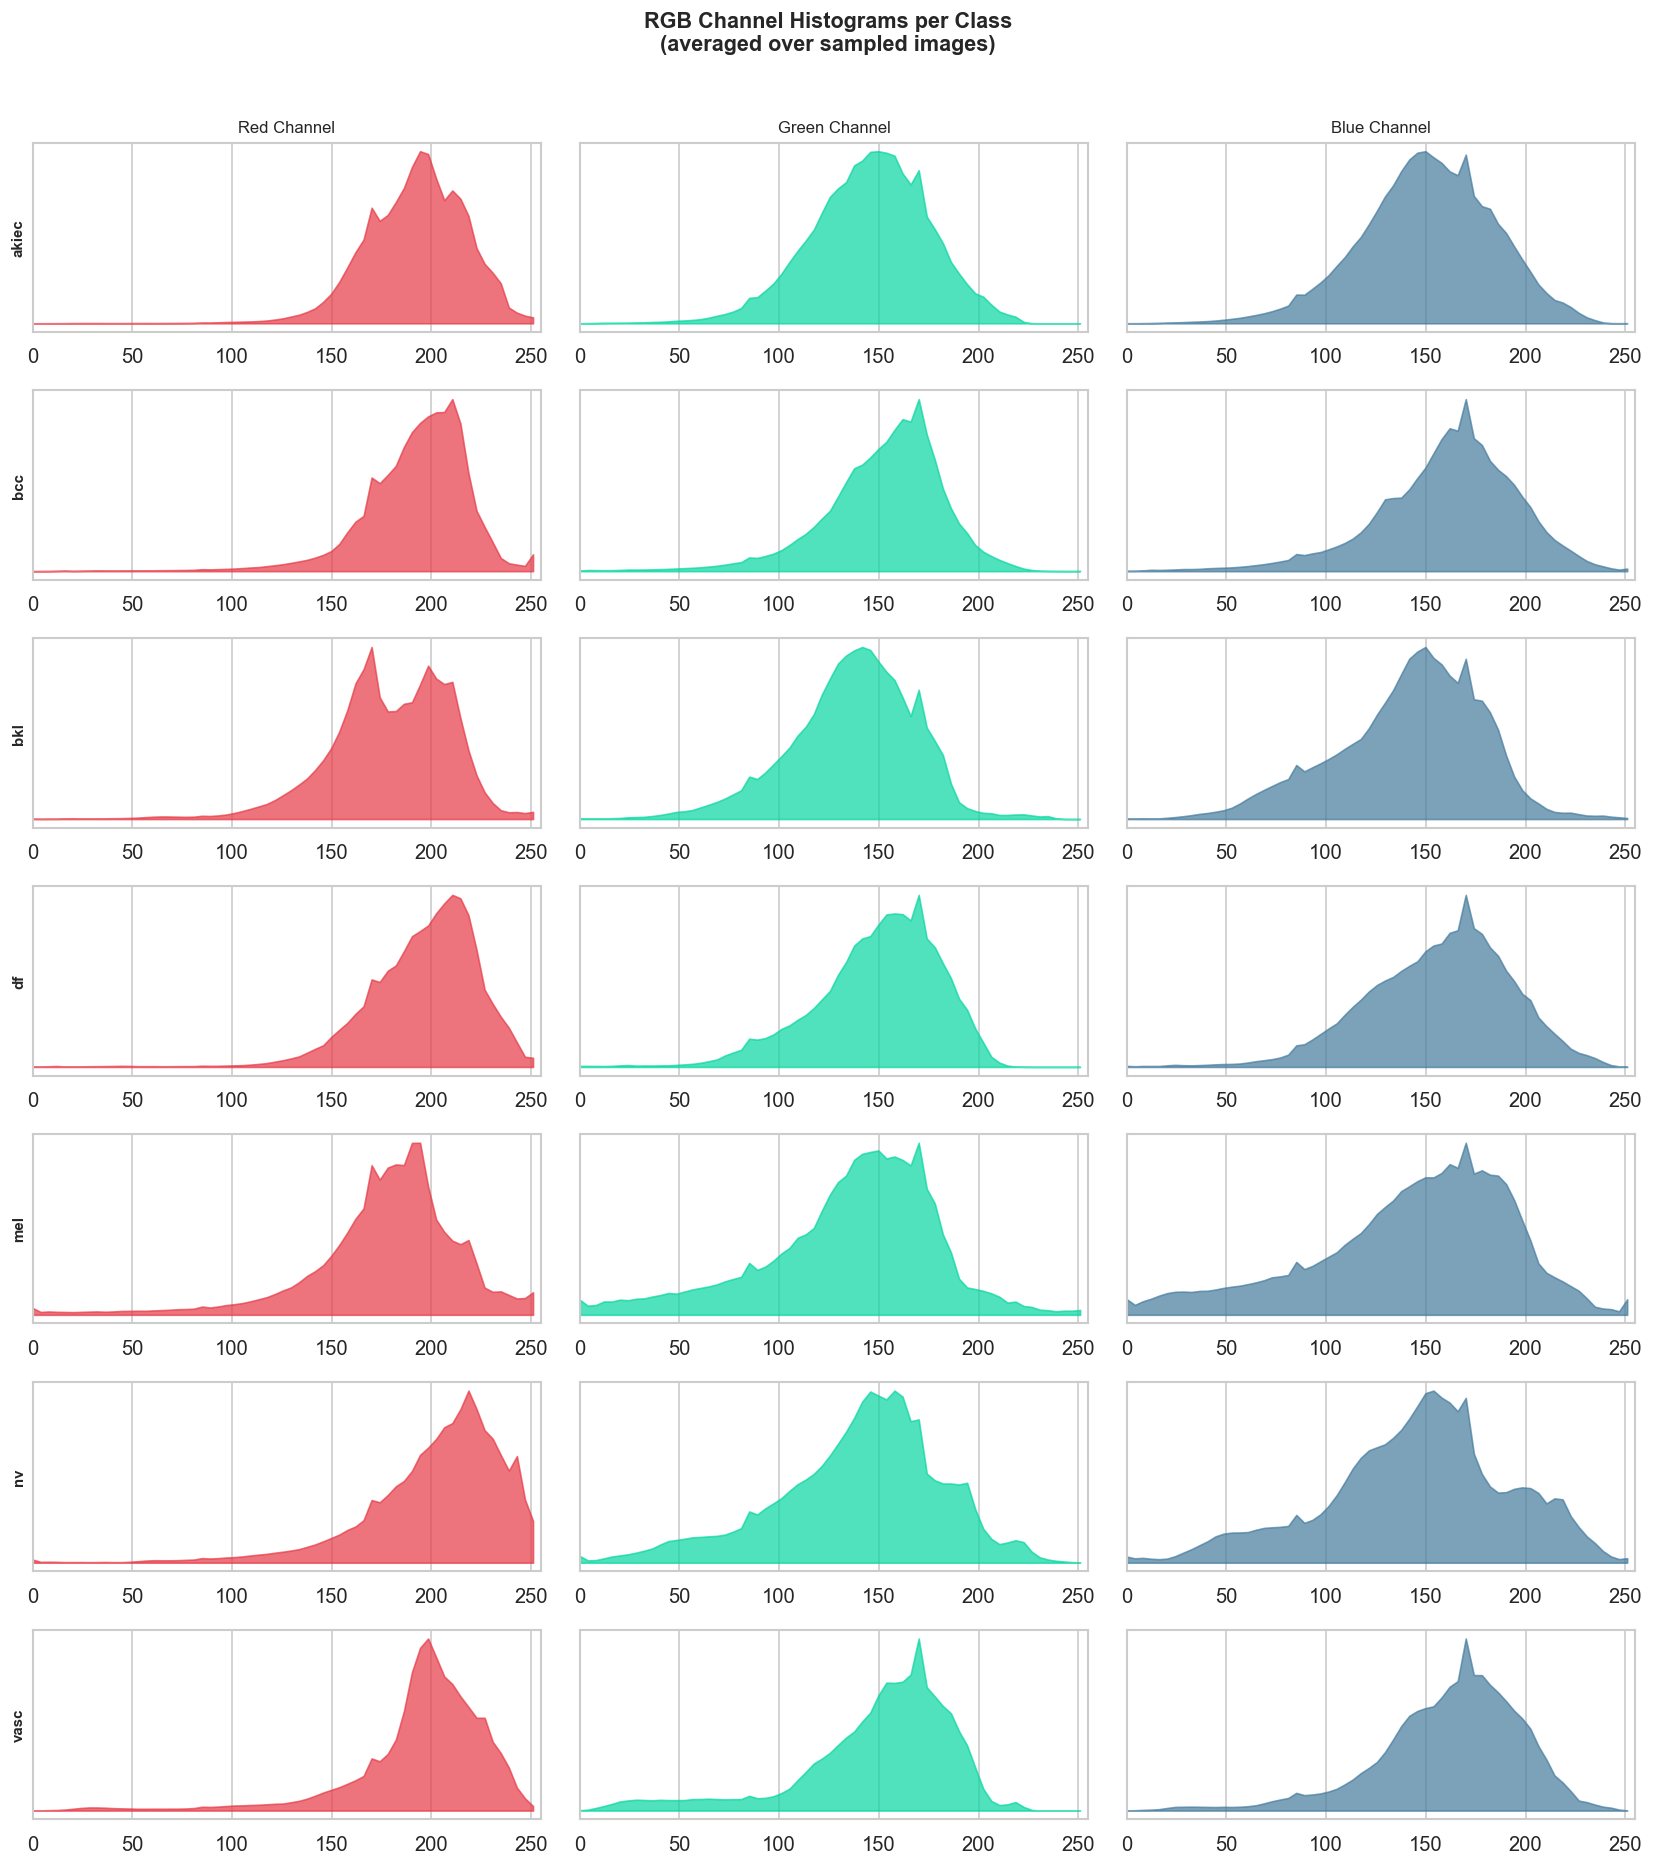

In [20]:
N_RGB_SAMPLE = 50   # images per class for histogram computation
bins = np.linspace(0, 255, 64)

fig, axes_grid = plt.subplots(len(classes), 3, figsize=(14, len(classes) * 2.2), sharey=False)
channel_names = ['Red', 'Green', 'Blue']
channel_colors = ['#E63946', '#06D6A0', '#457B9D']

for row_idx, cls in enumerate(classes):
    cls_df = df[df['dx'] == cls].dropna(subset=['img_path'])
    sampled = cls_df.sample(min(N_RGB_SAMPLE, len(cls_df)), random_state=SEED)

    channel_hists = [np.zeros(len(bins) - 1) for _ in range(3)]

    for _, row in sampled.iterrows():
        img_np = np.array(load_image_pil(row['img_path'])) if load_image_pil(row['img_path']) else None
        if img_np is None:
            continue
        for ch in range(3):
            h, _ = np.histogram(img_np[:, :, ch].ravel(), bins=bins)
            channel_hists[ch] += h

    for col_idx in range(3):
        ax = axes_grid[row_idx][col_idx]
        ax.fill_between(bins[:-1], channel_hists[col_idx],
                        alpha=0.7, color=channel_colors[col_idx])
        ax.set_xlim(0, 255)
        ax.set_yticks([])
        if row_idx == 0:
            ax.set_title(f'{channel_names[col_idx]} Channel', fontsize=10)
        if col_idx == 0:
            ax.set_ylabel(cls, fontsize=9, fontweight='bold')

plt.suptitle('RGB Channel Histograms per Class\n(averaged over sampled images)',
             y=1.01, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.3 Average colour per class

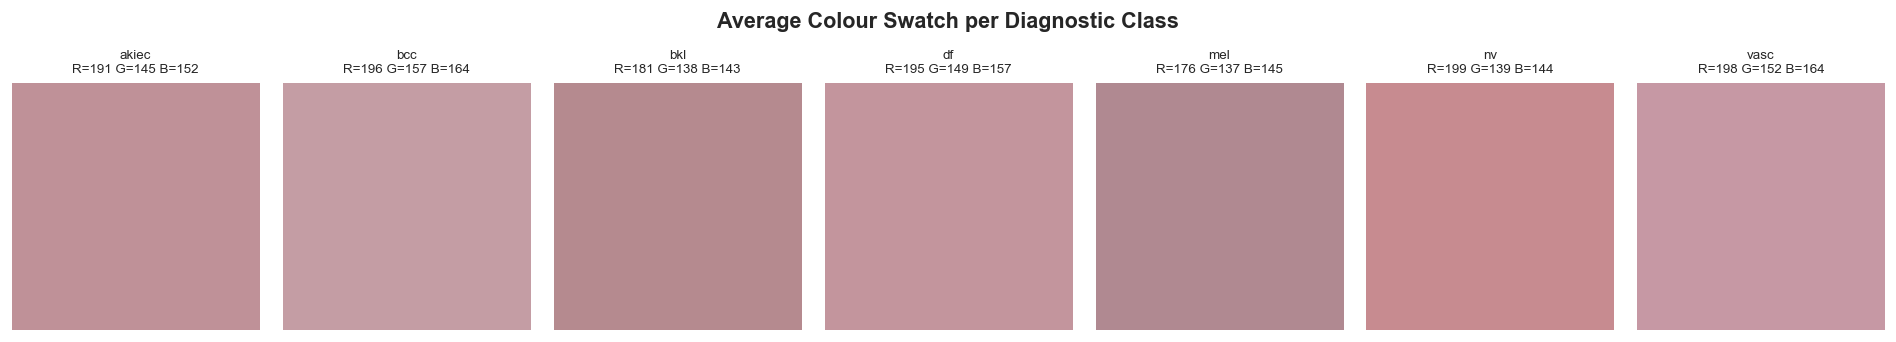

In [21]:
N_AVG_SAMPLE = 30
avg_colors = {}

for cls in classes:
    cls_df = df[df['dx'] == cls].dropna(subset=['img_path'])
    sampled = cls_df.sample(min(N_AVG_SAMPLE, len(cls_df)), random_state=SEED)
    means = []
    for _, row in sampled.iterrows():
        img = load_image_pil(row['img_path'])
        if img is not None:
            means.append(np.array(img).mean(axis=(0, 1)))
    if means:
        avg_colors[cls] = np.mean(means, axis=0).astype(np.uint8)

fig, axes = plt.subplots(1, len(classes), figsize=(16, 3))
for ax, cls in zip(axes, classes):
    if cls in avg_colors:
        swatch = np.ones((100, 100, 3), dtype=np.uint8) * avg_colors[cls]
        ax.imshow(swatch)
        r, g, b = avg_colors[cls]
        ax.set_title(f'{cls}\nR={r} G={g} B={b}', fontsize=8)
    ax.axis('off')

plt.suptitle('Average Colour Swatch per Diagnostic Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.4 Mean pixel intensity per class

Computing mean intensities:   0%|          | 0/7 [00:00<?, ?it/s]

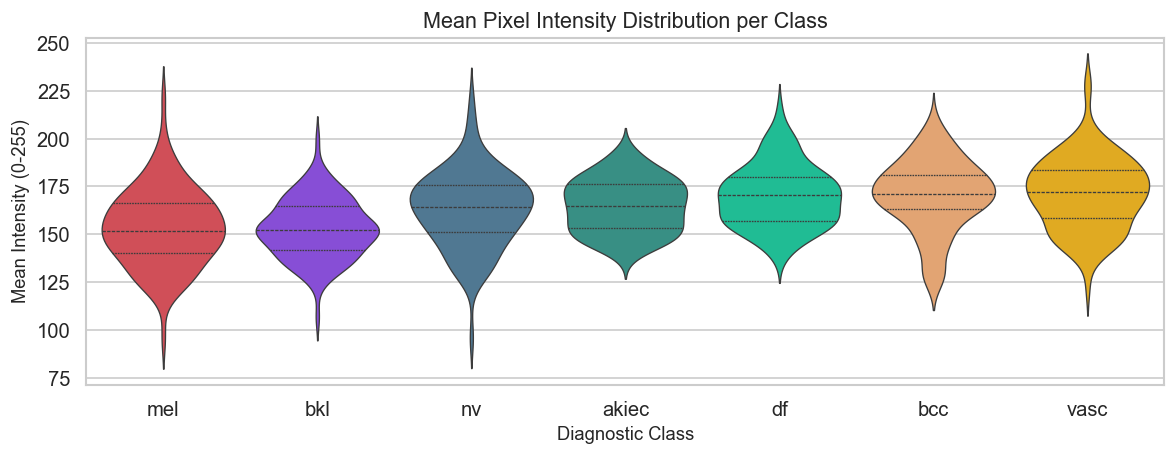

In [22]:
N_INTENSITY = 100
intensity_data = []

for cls in tqdm(classes, desc='Computing mean intensities'):
    cls_df = df[df['dx'] == cls].dropna(subset=['img_path'])
    sampled = cls_df.sample(min(N_INTENSITY, len(cls_df)), random_state=SEED)
    for _, row in sampled.iterrows():
        img = load_image_pil(row['img_path'])
        if img is not None:
            intensity_data.append({'dx': cls, 'mean_intensity': np.array(img).mean()})

int_df = pd.DataFrame(intensity_data)

fig, ax = plt.subplots(figsize=(10, 4))
order = int_df.groupby('dx')['mean_intensity'].median().sort_values().index
sns.violinplot(ax=ax, data=int_df, x='dx', y='mean_intensity', order=order,
               palette=CLASS_PALETTE, inner='quartile', linewidth=0.8)
ax.set_title('Mean Pixel Intensity Distribution per Class')
ax.set_xlabel('Diagnostic Class')
ax.set_ylabel('Mean Intensity (0-255)')
plt.tight_layout()
plt.show()

---
## 5 — Lesion-Level Analysis

Multiple images can correspond to the same physical lesion (`lesion_id`). This section quantifies that multiplicity and discusses its implications for train/validation splitting.

In [23]:
images_per_lesion = df.groupby('lesion_id')['image_id'].count().rename('n_images')
n_multi   = (images_per_lesion > 1).sum()
n_single  = (images_per_lesion == 1).sum()

print('=== Lesion multiplicity summary ===')
print(f'  Total unique lesions     : {len(images_per_lesion):,}')
print(f'  Lesions with 1 image     : {n_single:,}  ({n_single/len(images_per_lesion)*100:.1f}%)')
print(f'  Lesions with >1 image    : {n_multi:,}  ({n_multi/len(images_per_lesion)*100:.1f}%)')
print(f'  Max images for 1 lesion  : {images_per_lesion.max()}')
print(f'  Mean images per lesion   : {images_per_lesion.mean():.2f}')

=== Lesion multiplicity summary ===
  Total unique lesions     : 7,470
  Lesions with 1 image     : 5,514  (73.8%)
  Lesions with >1 image    : 1,956  (26.2%)
  Max images for 1 lesion  : 6
  Mean images per lesion   : 1.34


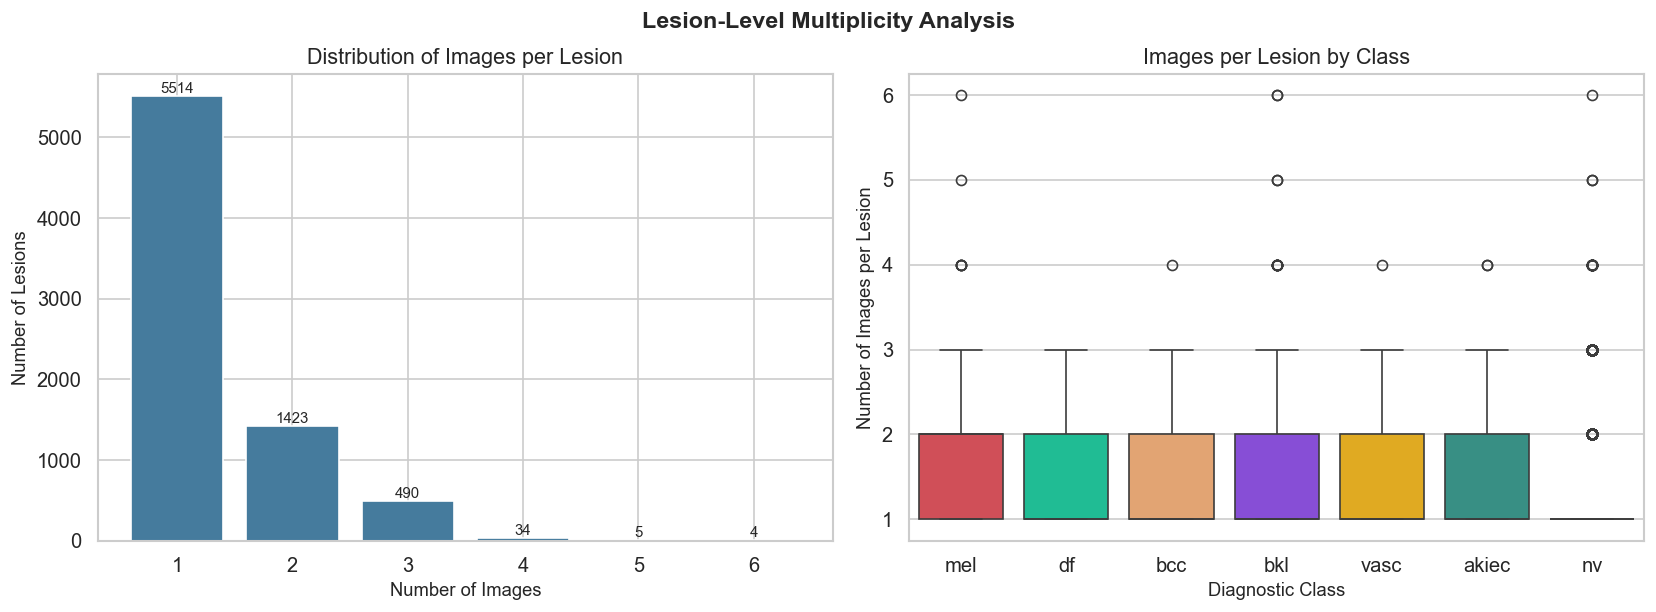

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of images per lesion
val_counts = images_per_lesion.value_counts().sort_index()
axes[0].bar(val_counts.index, val_counts.values, color='#457B9D', edgecolor='white')
axes[0].set_title('Distribution of Images per Lesion')
axes[0].set_xlabel('Number of Images')
axes[0].set_ylabel('Number of Lesions')
axes[0].set_xticks(val_counts.index)
for p, v in zip(axes[0].patches, val_counts.values):
    axes[0].text(p.get_x() + p.get_width() / 2, p.get_height() + 5,
                 str(v), ha='center', va='bottom', fontsize=9)

# Images per lesion by class
lesion_class = df.groupby('lesion_id').agg(n_images=('image_id', 'count'), dx=('dx', 'first')).reset_index()
order_cls = lesion_class.groupby('dx')['n_images'].mean().sort_values(ascending=False).index
sns.boxplot(ax=axes[1], data=lesion_class, x='dx', y='n_images', order=order_cls,
            palette=CLASS_PALETTE)
axes[1].set_title('Images per Lesion by Class')
axes[1].set_xlabel('Diagnostic Class')
axes[1].set_ylabel('Number of Images per Lesion')

plt.tight_layout()
plt.suptitle('Lesion-Level Multiplicity Analysis', y=1.02, fontsize=14, fontweight='bold')
plt.show()

In [25]:
# Data leakage risk report
high_mult = images_per_lesion[images_per_lesion > 1]
total_images_with_duplicates = df[df['lesion_id'].isin(high_mult.index)].shape[0]

print('=== Data Leakage Risk Assessment ===')
print(f'  Lesions with duplicate images : {len(high_mult):,}')
print(f'  Images belonging to such lesions : {total_images_with_duplicates:,}')
print(f'  Proportion of dataset at risk : {total_images_with_duplicates/len(df)*100:.1f}%')
print()
print('  ⚠  If a random image-level split is used, images of the same lesion')
print('     can appear in both training and validation sets, causing optimistic')
print('     performance estimates.  Use a lesion-stratified split to ensure')
print('     that all images of a given lesion belong to the same fold.')

=== Data Leakage Risk Assessment ===
  Lesions with duplicate images : 1,956
  Images belonging to such lesions : 4,501
  Proportion of dataset at risk : 44.9%

  ⚠  If a random image-level split is used, images of the same lesion
     can appear in both training and validation sets, causing optimistic
     performance estimates.  Use a lesion-stratified split to ensure
     that all images of a given lesion belong to the same fold.


---
## 6 — Dataset Imbalance Analysis

Class imbalance is one of the most critical challenges when training classification models on HAM10000.

Majority class : nv (Melanocytic Nevi) — 6,705 images
Minority class : df (Dermatofibroma) — 115 images
Imbalance ratio (majority/minority) : 58.3:1


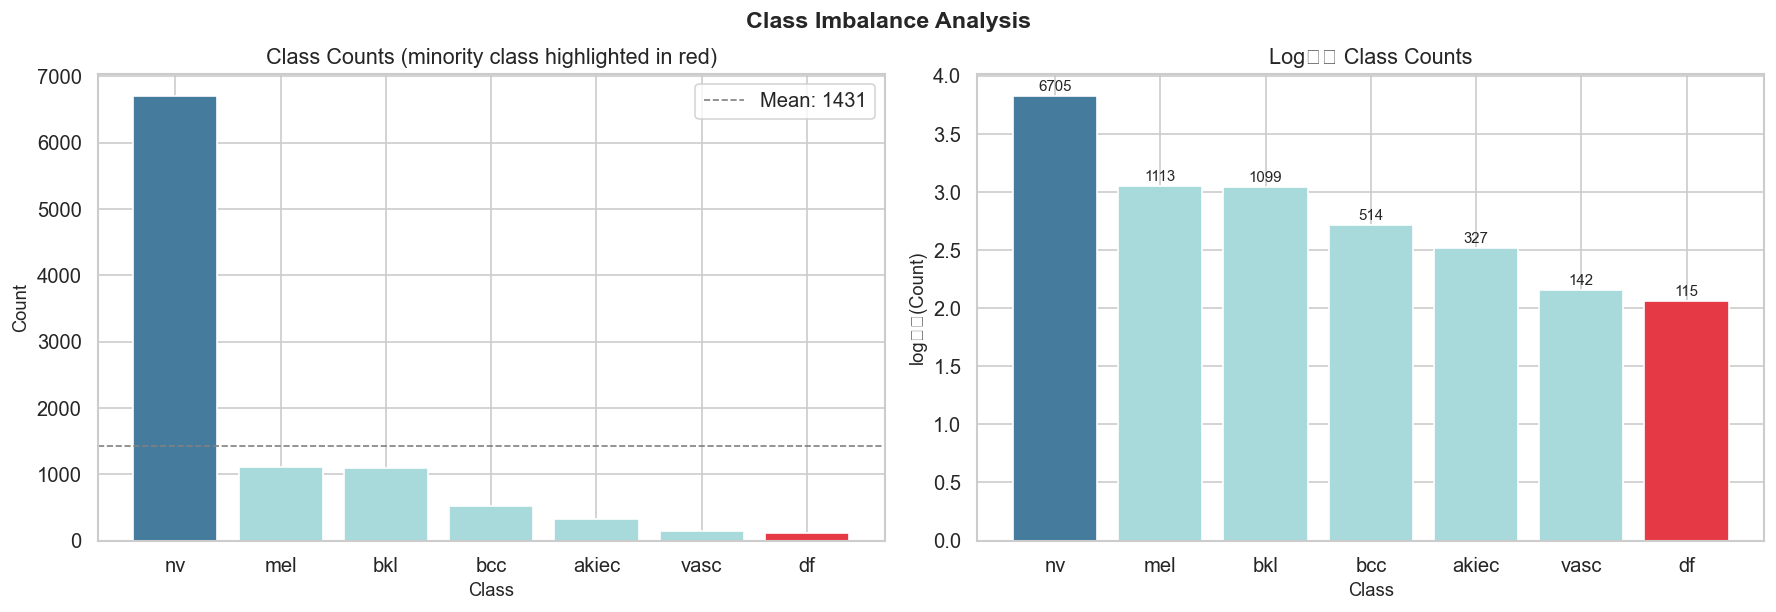

In [26]:
majority_class = dx_counts.idxmax()
minority_class = dx_counts.idxmin()

imbalance_ratio = dx_counts[majority_class] / dx_counts[minority_class]
print(f'Majority class : {majority_class} ({CLASS_LABELS[majority_class]}) — {dx_counts[majority_class]:,} images')
print(f'Minority class : {minority_class} ({CLASS_LABELS[minority_class]}) — {dx_counts[minority_class]:,} images')
print(f'Imbalance ratio (majority/minority) : {imbalance_ratio:.1f}:1')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Absolute count with minority highlighted
bar_colors = ['#E63946' if c == minority_class else
              '#457B9D' if c == majority_class else '#A8DADC'
              for c in dx_counts.index]
bars = axes[0].bar(dx_counts.index, dx_counts.values, color=bar_colors, edgecolor='white')
axes[0].set_title('Class Counts (minority class highlighted in red)')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].axhline(dx_counts.mean(), color='gray', linestyle='--', linewidth=1,
                label=f'Mean: {dx_counts.mean():.0f}')
axes[0].legend()

# Effective Number of Samples (log scale)
axes[1].bar(dx_counts.index, np.log10(dx_counts.values), color=bar_colors, edgecolor='white')
axes[1].set_title('Log₁₀ Class Counts')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('log₁₀(Count)')
for i, (cls, cnt) in enumerate(dx_counts.items()):
    axes[1].text(i, np.log10(cnt) + 0.02, f'{cnt}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.suptitle('Class Imbalance Analysis', y=1.02, fontsize=14, fontweight='bold')
plt.show()

### 6.1 Recommended mitigation strategies

In [27]:
# Compute what factors would be needed to balance classes by oversampling
target_n = dx_counts.max()

resampling_df = pd.DataFrame({
    'Class'        : dx_counts.index,
    'Full Name'    : [CLASS_LABELS[c] for c in dx_counts.index],
    'Current N'    : dx_counts.values,
    'Target N'     : target_n,
    'Augment factor (×)': (target_n / dx_counts.values).round(1),
}).set_index('Class')

print('Recommended augmentation factors to balance classes:')
display(resampling_df)

print('\n=== Recommended preprocessing and augmentation techniques ===')
recommendations = [
    '1. Lesion-stratified train/val split to prevent data leakage.',
    '2. Class-weighted cross-entropy loss (inversely proportional to class frequency).',
    '3. Oversampling minority classes via:',
    '     a. Random rotation (0–360°)',
    '     b. Horizontal and vertical flips',
    '     c. Random crop and zoom',
    '     d. Colour jitter (brightness, contrast, saturation, hue)',
    '     e. Elastic deformation / grid distortion',
    '4. Hair removal preprocessing (DullRazor algorithm) to reduce artefacts.',
    '5. Image normalisation using per-channel mean/std computed on training set.',
    '6. Consider mixup or CutMix augmentation for improved generalisation.',
    '7. Focal loss as an alternative to weighted cross-entropy.',
]
for r in recommendations:
    print(r)

Recommended augmentation factors to balance classes:


,Full Name,Current N,Target N,Augment factor (×)
Class,,,,
nv,Melanocytic Nevi,6705,6705,1.00
mel,Melanoma,1113,6705,6.00
bkl,Benign Keratosis-like Lesions,1099,6705,6.10
bcc,Basal Cell Carcinoma,514,6705,13.00
akiec,Actinic Keratosis / Intraepithelial Carcinoma,327,6705,20.50
vasc,Vascular Lesions,142,6705,47.20
df,Dermatofibroma,115,6705,58.30



=== Recommended preprocessing and augmentation techniques ===
1. Lesion-stratified train/val split to prevent data leakage.
2. Class-weighted cross-entropy loss (inversely proportional to class frequency).
3. Oversampling minority classes via:
     a. Random rotation (0–360°)
     b. Horizontal and vertical flips
     c. Random crop and zoom
     d. Colour jitter (brightness, contrast, saturation, hue)
     e. Elastic deformation / grid distortion
4. Hair removal preprocessing (DullRazor algorithm) to reduce artefacts.
5. Image normalisation using per-channel mean/std computed on training set.
6. Consider mixup or CutMix augmentation for improved generalisation.
7. Focal loss as an alternative to weighted cross-entropy.


---
## 7 — Segmentation Mask Analysis

The dataset includes binary segmentation masks delineating the lesion boundary, provided by Tschandl et al. (2019).

In [28]:
# Verify mask availability
df['mask_path'] = df['image_id'].apply(resolve_mask_path)
mask_available = df['mask_path'].notna().sum()

print(f'Masks found     : {mask_available:,}')
print(f'Masks missing   : {df["mask_path"].isna().sum()}')

Masks found     : 10,015
Masks missing   : 0


### 7.1 Image vs mask overlay — one example per class

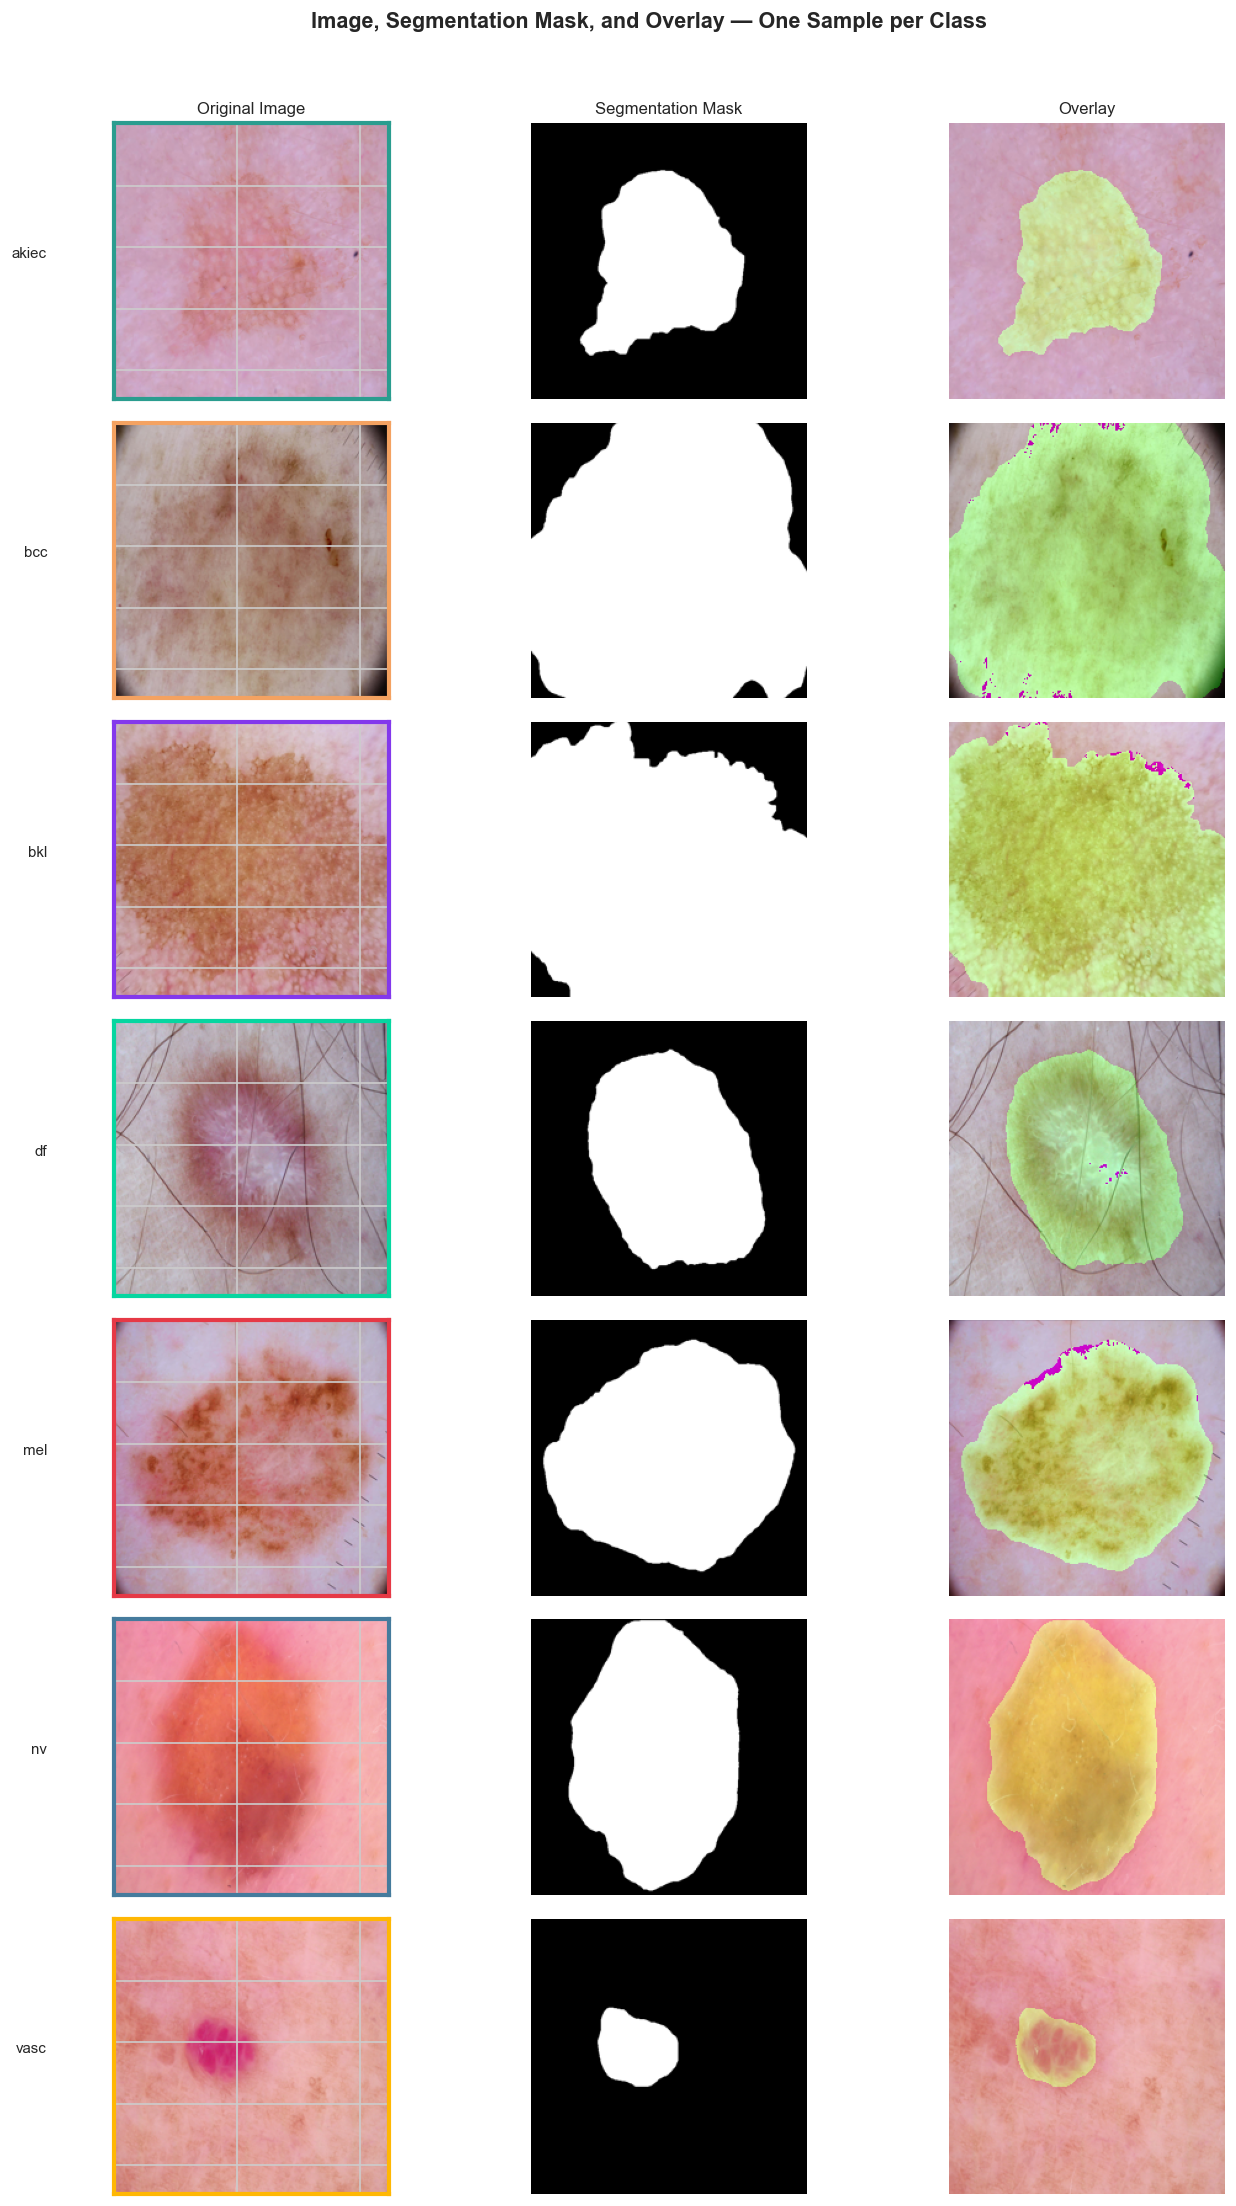

In [29]:
fig, axes = plt.subplots(len(classes), 3, figsize=(12, len(classes) * 2.6))
col_labels = ['Original Image', 'Segmentation Mask', 'Overlay']

for row_idx, cls in enumerate(classes):
    cls_df = df[(df['dx'] == cls) & df['img_path'].notna() & df['mask_path'].notna()]
    if len(cls_df) == 0:
        for ax in axes[row_idx]:
            ax.axis('off')
        continue

    row = cls_df.sample(1, random_state=SEED).iloc[0]
    img    = load_image_pil(row['img_path'])
    mask_p = row['mask_path']

    try:
        mask = Image.open(mask_p).convert('L')
    except Exception:
        for ax in axes[row_idx]:
            ax.axis('off')
        continue

    img_resized  = img.resize((224, 224))
    mask_resized = mask.resize((224, 224))
    img_np  = np.array(img_resized)
    mask_np = np.array(mask_resized)

    # Overlay: green channel where mask is active
    overlay = img_np.copy()
    overlay[mask_np > 127, 1] = np.clip(overlay[mask_np > 127, 1] + 80, 0, 255)

    for col_idx, (data, cmap) in enumerate([(img_np, None), (mask_np, 'gray'), (overlay, None)]):
        ax = axes[row_idx][col_idx]
        ax.imshow(data, cmap=cmap)
        ax.axis('off')
        if row_idx == 0:
            ax.set_title(col_labels[col_idx], fontsize=10)
        if col_idx == 0:
            ax.set_ylabel(f'{cls}', fontsize=9, rotation=0, labelpad=40, va='center', ha='right')
            ax.yaxis.set_label_position('left')
            ax.axis('on')
            ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
            for spine in ax.spines.values():
                spine.set_edgecolor(CLASS_PALETTE[cls])
                spine.set_linewidth(2.5)

plt.suptitle('Image, Segmentation Mask, and Overlay — One Sample per Class',
             y=1.01, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.2 Lesion area statistics from segmentation masks

Computing mask areas:   0%|          | 0/200 [00:00<?, ?it/s]

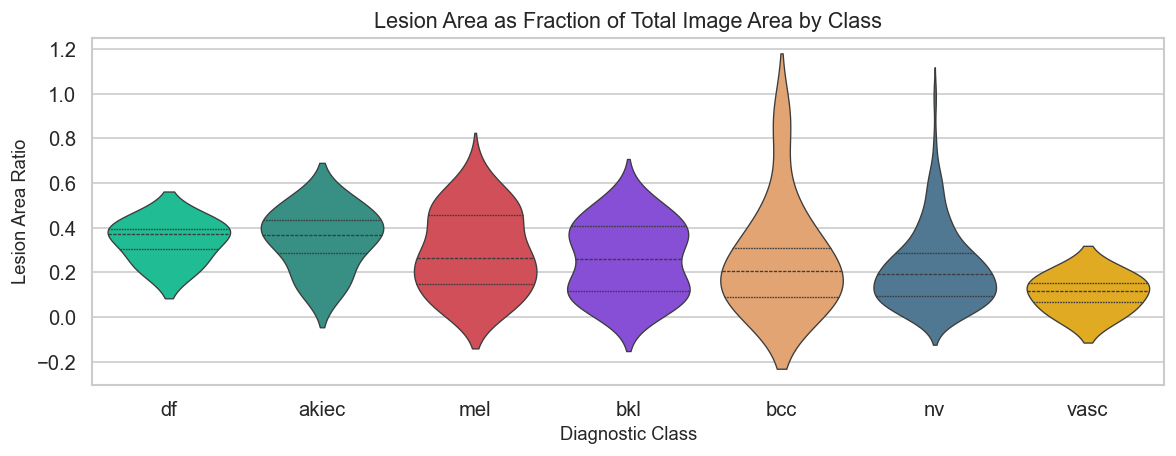

Lesion area ratio summary:


,count,mean,std,min,25%,50%,75%,max
dx,,,,,,,,
akiec,8.00,0.35,0.13,0.13,0.29,0.37,0.43,0.51
bcc,11.00,0.27,0.24,0.07,0.09,0.21,0.31,0.88
bkl,25.00,0.26,0.16,0.02,0.12,0.26,0.41,0.54
df,3.00,0.34,0.09,0.23,0.30,0.37,0.39,0.41
mel,27.00,0.29,0.18,0.04,0.15,0.26,0.46,0.64
nv,123.00,0.22,0.17,0.01,0.09,0.19,0.29,0.99
vasc,3.00,0.11,0.08,0.02,0.07,0.12,0.15,0.19


In [30]:
N_MASK_SAMPLE = 200
mask_stats = []

sample_mask_df = df[df['mask_path'].notna()].sample(N_MASK_SAMPLE, random_state=SEED)

for _, row in tqdm(sample_mask_df.iterrows(), total=N_MASK_SAMPLE, desc='Computing mask areas'):
    try:
        mask_np = np.array(Image.open(row['mask_path']).convert('L'))
        total_pixels = mask_np.size
        lesion_pixels = (mask_np > 127).sum()
        mask_stats.append({
            'dx'            : row['dx'],
            'lesion_ratio'  : lesion_pixels / total_pixels,
        })
    except Exception:
        pass

mask_df = pd.DataFrame(mask_stats)

fig, ax = plt.subplots(figsize=(10, 4))
order = mask_df.groupby('dx')['lesion_ratio'].median().sort_values(ascending=False).index
sns.violinplot(ax=ax, data=mask_df, x='dx', y='lesion_ratio', order=order,
               palette=CLASS_PALETTE, inner='quartile', linewidth=0.8)
ax.set_title('Lesion Area as Fraction of Total Image Area by Class')
ax.set_xlabel('Diagnostic Class')
ax.set_ylabel('Lesion Area Ratio')
plt.tight_layout()
plt.show()

print('Lesion area ratio summary:')
display(mask_df.groupby('dx')['lesion_ratio'].describe().round(3))

---
## 8 — Test Set Analysis

The ISIC 2018 Task 3 test set has 1,511 images and published ground truth labels.

In [31]:
print('Test ground truth shape:', df_test_gt.shape)
df_test_gt.head()

Test ground truth shape: (1512, 8)


,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset
0,HAMTEST_0000000,ISIC_0034524,nv,follow_up,40.00,female,back,vidir_molemax
1,HAMTEST_0000001,ISIC_0034525,nv,histo,70.00,male,abdomen,rosendahl
2,HAMTEST_0000002,ISIC_0034526,bkl,histo,70.00,male,back,rosendahl
3,HAMTEST_0000003,ISIC_0034527,nv,histo,35.00,male,trunk,vienna_dias
4,HAMTEST_0000004,ISIC_0034528,nv,follow_up,75.00,female,trunk,vidir_molemax


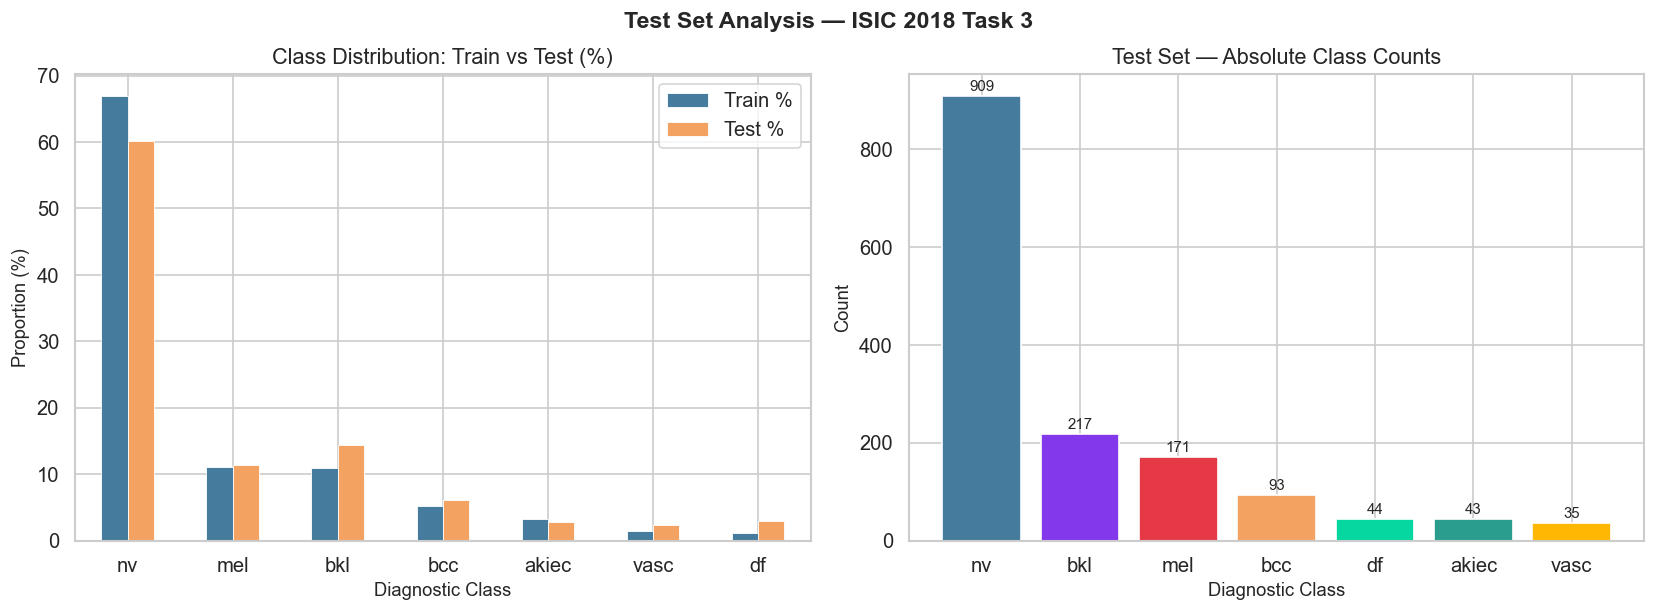

Test set size         : 1512
Unique classes in test: 7


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Compare train vs test class distributions
train_pct = (df['dx'].value_counts() / len(df) * 100).rename('Train %')
test_pct  = (df_test_gt['dx'].value_counts() / len(df_test_gt) * 100).rename('Test %')
comparison = pd.concat([train_pct, test_pct], axis=1).fillna(0)

comparison.plot(kind='bar', ax=axes[0], color=['#457B9D', '#F4A261'],
                edgecolor='white', linewidth=0.5)
axes[0].set_title('Class Distribution: Train vs Test (%)')
axes[0].set_xlabel('Diagnostic Class')
axes[0].set_ylabel('Proportion (%)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend()

# Test set absolute counts
test_counts = df_test_gt['dx'].value_counts()
test_colors = [CLASS_PALETTE.get(c, '#888') for c in test_counts.index]
axes[1].bar(test_counts.index, test_counts.values, color=test_colors, edgecolor='white')
axes[1].set_title('Test Set — Absolute Class Counts')
axes[1].set_xlabel('Diagnostic Class')
axes[1].set_ylabel('Count')
for p, v in zip(axes[1].patches, test_counts.values):
    axes[1].text(p.get_x() + p.get_width() / 2, p.get_height() + 5,
                 str(v), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.suptitle('Test Set Analysis — ISIC 2018 Task 3', y=1.02, fontsize=14, fontweight='bold')
plt.show()

print('Test set size         :', len(df_test_gt))
print('Unique classes in test:', df_test_gt['dx'].nunique())

---
## 9 — Summary Statistics Dashboard

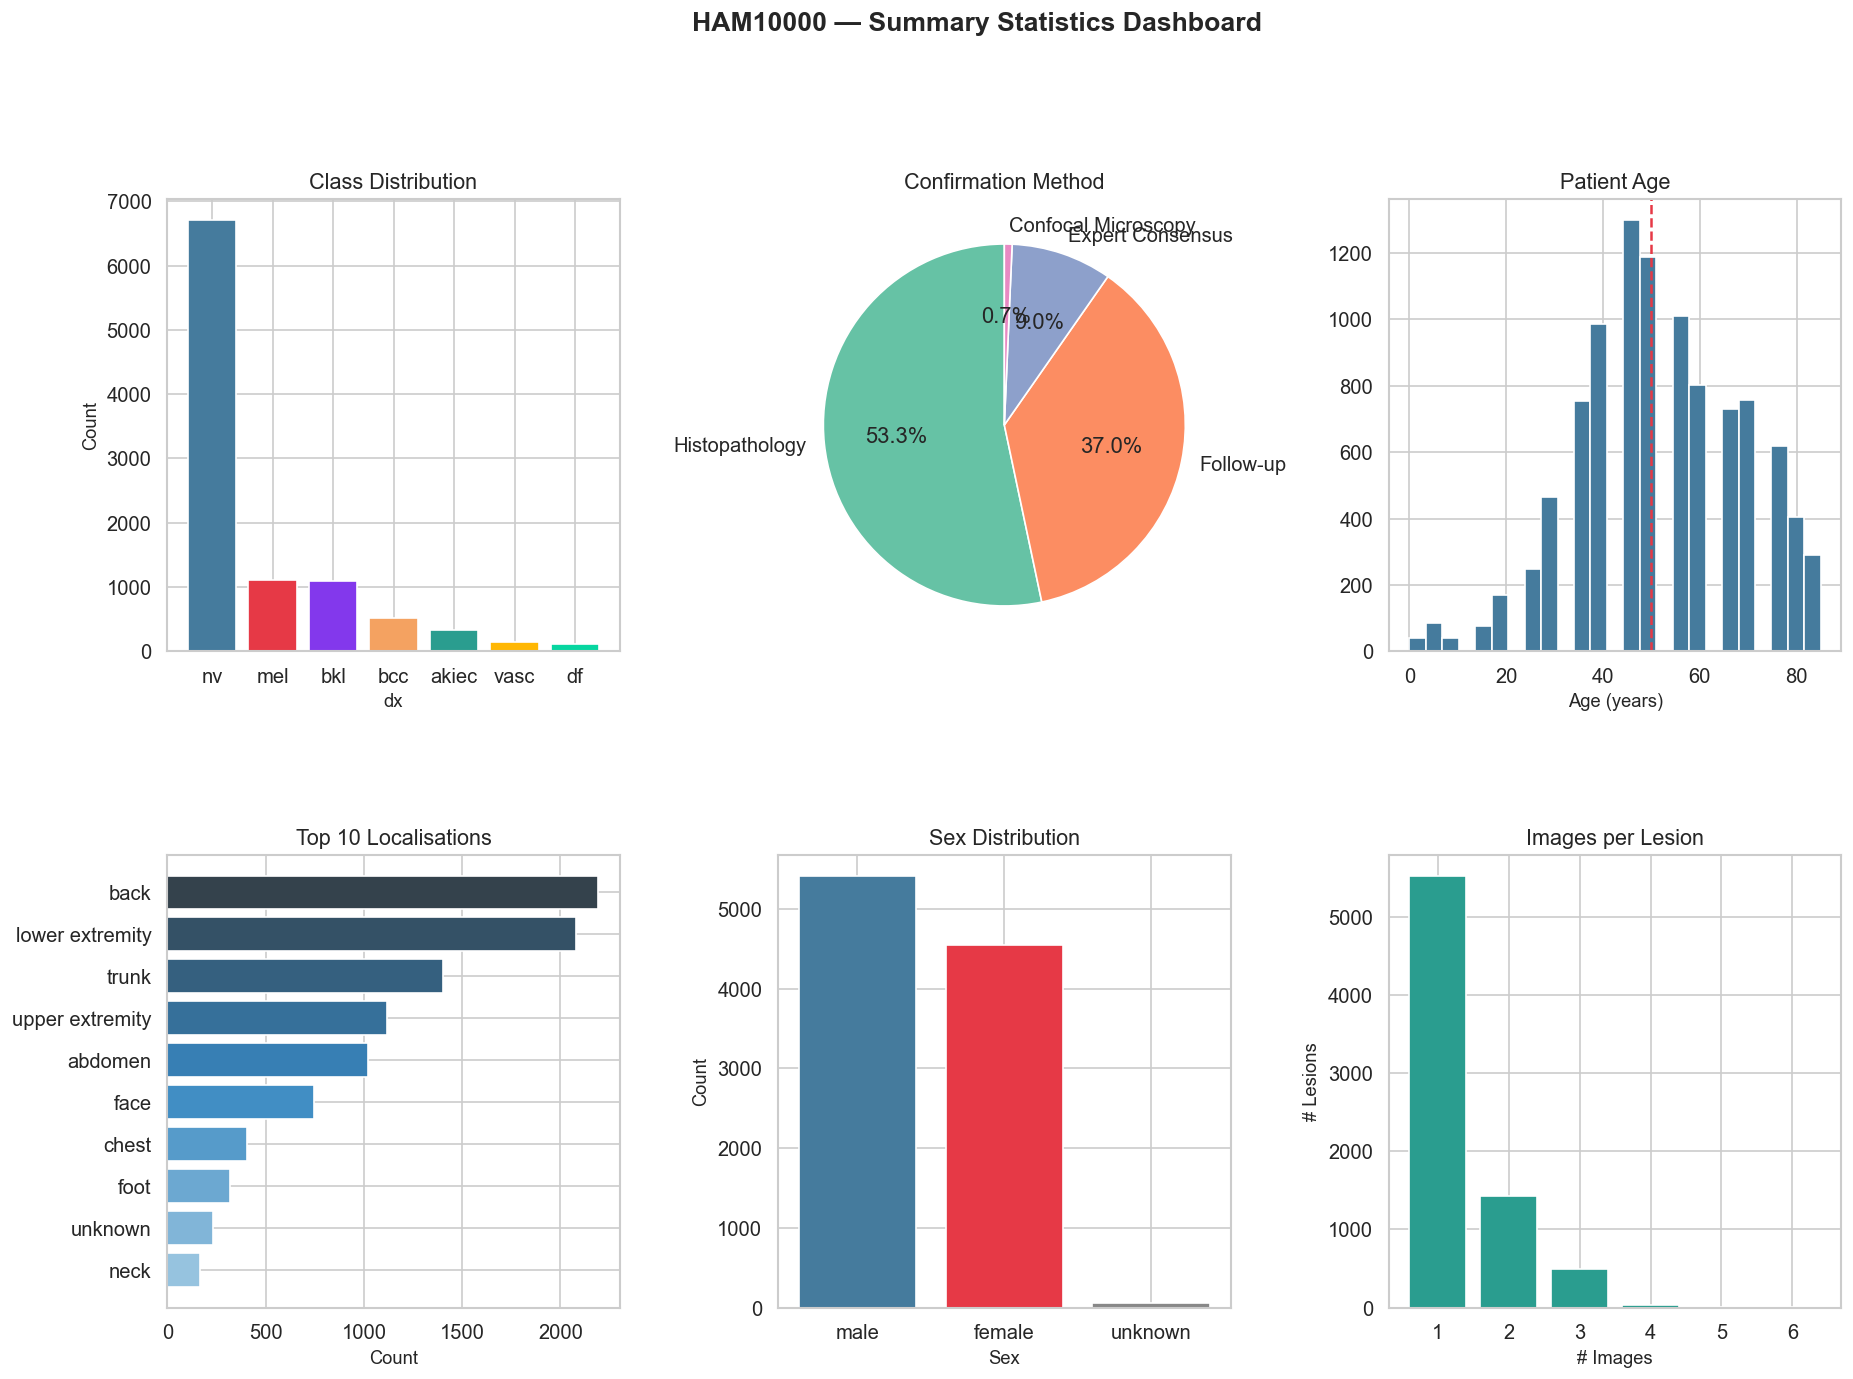

In [33]:
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])  # Class counts
ax2 = fig.add_subplot(gs[0, 1])  # dx_type
ax3 = fig.add_subplot(gs[0, 2])  # Age
ax4 = fig.add_subplot(gs[1, 0])  # Localization
ax5 = fig.add_subplot(gs[1, 1])  # Sex
ax6 = fig.add_subplot(gs[1, 2])  # Images per lesion

# 1. Class counts
colors_cls = [CLASS_PALETTE[c] for c in dx_counts.index]
ax1.bar(dx_counts.index, dx_counts.values, color=colors_cls, edgecolor='white')
ax1.set_title('Class Distribution')
ax1.set_xlabel('dx')
ax1.set_ylabel('Count')

# 2. dx_type
dxt = df['dx_type'].value_counts()
ax2.pie(dxt.values, labels=[dx_type_labels.get(k, k) for k in dxt.index],
        colors=sns.color_palette('Set2', len(dxt)),
        autopct='%1.1f%%', startangle=90)
ax2.set_title('Confirmation Method')

# 3. Age
ax3.hist(df['age'].dropna(), bins=25, color='#457B9D', edgecolor='white')
ax3.axvline(df['age'].median(), color='#E63946', linestyle='--', linewidth=1.5)
ax3.set_title('Patient Age')
ax3.set_xlabel('Age (years)')

# 4. Top localizations
top_locs_10 = df['localization'].value_counts().head(10)
ax4.barh(top_locs_10.index[::-1], top_locs_10.values[::-1],
         color=sns.color_palette('Blues_d', 10))
ax4.set_title('Top 10 Localisations')
ax4.set_xlabel('Count')

# 5. Sex
sc = df['sex'].value_counts()
ax5.bar(sc.index, sc.values,
        color=[sex_palette.get(s, '#888') for s in sc.index], edgecolor='white')
ax5.set_title('Sex Distribution')
ax5.set_xlabel('Sex')
ax5.set_ylabel('Count')

# 6. Images per lesion
ax6.bar(val_counts.index, val_counts.values, color='#2A9D8F', edgecolor='white')
ax6.set_title('Images per Lesion')
ax6.set_xlabel('# Images')
ax6.set_ylabel('# Lesions')

plt.suptitle('HAM10000 — Summary Statistics Dashboard', fontsize=16, fontweight='bold', y=1.01)
plt.show()

---
## 10 — Conclusions

The following section synthesises the key findings from the EDA.

### 10.1 Summary of findings

| Dimension | Key Finding |
|-----------|-------------|
| **Dataset size** | 10,015 training images; 7,470 unique lesions across 7 diagnostic classes. |
| **Class imbalance** | Severely skewed: *Melanocytic Nevi* accounts for ≈67 % of images; *Vascular Lesions* and *Dermatofibroma* together account for < 4 %. The majority/minority imbalance ratio is ≈58:1. |
| **Diagnosis quality** | ≈56 % of images are confirmed by histopathology (gold standard). The remainder use follow-up, expert consensus, or confocal microscopy — varying levels of label confidence that may introduce label noise in training. |
| **Demographics** | Patients aged 0–85 years; median ≈ 45 years. Male and female patients are roughly balanced (~53 % / ~47 %). The back, lower extremity, and trunk are the most common body sites. |
| **Image properties** | All images are 600 × 450 px JPEGs in RGB colour space. No corrupted files were detected. The aspect ratio is uniform (4:3). |
| **Lesion multiplicity** | A significant proportion of lesions have more than one image (e.g., photographed at different times or with different equipment). A naïve random image-level split will leak information across train and validation partitions. A **lesion-stratified split** is mandatory. |
| **Segmentation masks** | Binary masks are available for all 10,015 training images. Lesion-to-image area ratios vary widely across classes, with melanomas generally occupying a larger fraction of the frame. |
| **Test set** | The 1,511 test images maintain a distribution qualitatively similar to the training set, with the same class imbalance pattern. |

---

### 10.2 Challenges for deep learning

1. **Severe class imbalance** — A classifier trained without countermeasures will be biased towards predicting *nv* for nearly all inputs. Weighted loss or oversampling is essential.
2. **Data leakage via lesion multiplicity** — Any performance metric computed with a random split over images (rather than lesions) will be optimistically biased.
3. **Heterogeneous acquisition conditions** — Images from different institutions, acquisition times, and dermoscopes exhibit differences in colour balance, magnification, and hair/artefact prevalence, demanding robust augmentation.
4. **Label noise from non-histological confirmation** — Approximately 44 % of labels are based on follow-up or consensus; these carry higher uncertainty and may degrade training.
5. **Small lesion size in some classes** — Vascular lesions and dermatofibromas can be subtle and visually similar to benign lesions, posing a fine-grained discrimination challenge.

---

### 10.3 Recommended preprocessing pipeline

```
Raw JPEG  →  Hair removal (DullRazor)  →  Resize to 224×224 (or 299×299)
          →  Per-channel normalisation (ImageNet statistics)
          →  Lesion-stratified 5-fold cross-validation split
          →  Online augmentation (flip, rotate, colour jitter, elastic)
          →  Class-weighted cross-entropy or Focal Loss
```

---

*End of EDA Notebook. All analysis is fully reproducible: set `SEED = 42` and ensure the dataset is available under the paths defined in Section 0.*